# 1L2Tau — Consolidated Signal vs Background Analysis Pipeline

This notebook consolidates and reorganizes the separate, duplicated exploration
notebooks (`First_Training.ipynb`, `Combined_Runs.ipynb`, `Comparison.ipynb`,
`Yields.ipynb`) into a single, documented pipeline for the **1 lepton + 2 tau**
(1l2tau) channel.

Instead of copy-pasting the same loading / training / pruning code once per run
(as the original notebooks did), the logic is written **once** as a small library
of helper functions (Section 2), and each run just calls those functions. This
keeps the three tracks below consistent by construction instead of by
copy-paste discipline.

**Processes:** `signal_ggF` + `signal_VBF` (label = 1) vs. `Diboson`, `Zjets`,
`Wjets`, `ttbar`, `tops`, `SingleH`, `Vgamma`, `VVV` (label = 0).

**Preselection** (see repo `README.md`): `n_b_jet == 0` and `n_jet >= 2`.

**Physical event weight:** `w_phys = weight * weights` (`weight` = per-DSID/
campaign normalization, `weights` = Sherpa NLO generator weight, which can be
negative). `|w_phys|` is used for training/AUC; the sign is only relevant for
yields.

## Contents

1. Setup & global configuration (paths, preselection, leakage-free feature policy)
2. Shared helper function library (load/clean/yields/split/train/prune/tune/plot)
3. **Run 2 only** — load → yields → baseline → correlation pruning → Optuna tuning
4. **Run 3 only** — same steps as Run 2, independently
5. **Run 2 + Run 3 combined** — same steps on the chained sample, plus a
   comparison of the three tracks' feature rankings
6. **Run 2 vs Run 3 domain-shift check** — a separate classifier whose only job
   is telling Run 2 signal events apart from Run 3 signal events (AUC ≈ 0.5
   means the two campaigns are indistinguishable in the features that matter)
7. Summary — consolidated AUC comparison and saved artifacts

**Note:** this notebook is written to be run top-to-bottom, but has **not**
been executed yet — cell outputs (yields, AUCs, plots) will appear the first
time you run it against the ROOT files in `PPSSP_2026/1l2tau/`.


## 1. Setup & Global Configuration

Paths, tree name, preselection cut and the leakage-free feature-selection
policy. These are shared by every section below, so they're defined once,
here, instead of being re-declared (and risking drift) in each track.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

# GPU-resident arrays - lets XGBoost train/eval/predict entirely on the GPU
# instead of needing a CPU<->GPU fallback copy every time (see `to_device` in
# Section 2). Optional: falls back to plain numpy if cupy isn't installed -
# `pip install cupy-cuda12x` to match this machine's CUDA 12.9 toolkit. GPU
# training with device="cuda" still works without cupy, just with the
# occasional "mismatched devices" warning during eval/predict.

try:
    import cupy as cp
except ImportError:
    cp = None

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
BASE_DIR_R2 = Path("PPSSP_2026/1l2tau/run2")   # 1 lepton + 2 taus, Run 2
BASE_DIR_R3 = Path("PPSSP_2026/1l2tau/run3")   # 1 lepton + 2 taus, Run 3
TREE_NAME   = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "1 Lepton 2 Taus")
# ---------------------------------------------------------------------------
PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background). The SAME 10 files
# are used for every track (Run 2, Run 3, combined) so results stay comparable.
# ---------------------------------------------------------------------------
FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]   # raw branches; w_phys = their product

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy
# ---------------------------------------------------------------------------
# Load candidate branches generously and let XGBoost + correlation pruning
# narrow them down later, BUT never let these branches enter as *features* -
# they would poison training / leak the label:
#   - weights & scale/fake factors -> differ systematically signal vs bkg
#   - dsid / eventNumber           -> sample/event identifiers (label in disguise)
#   - *truth* / isTrue* / *fake*   -> generator info, absent in real data
#   - anti-tau bookkeeping         -> fake-region definition, process-dependent
#   - preselection constants       -> n_b_jet==0 always; pass1l2tau==1 always

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT = {
    "n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig",
}
BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:
    """True if `branch` is safe to use as a training feature (see policy above)."""
    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)


# ---------------------------------------------------------------------------
# Shared knobs - single named constants instead of literals scattered (and
# drifting) across cells. NOTE: the original notebooks had N_TRIALS silently
# drift to 5 for the Run-2 Optuna search while Run-3 hardcoded 15 to
# compensate - N_OPTUNA_TRIALS below is passed explicitly everywhere so that
# can't happen here.
# ---------------------------------------------------------------------------

TOP_N_IMPORTANCE = 30    # how many features to inspect after the baseline model
CORR_THRESH      = 0.75  # |corr| above this -> considered redundant
N_KEEP           = 20    # decorrelated features to keep after pruning
N_OPTUNA_TRIALS  = 15    # trials for every Optuna search in this notebook
N_OPTUNA_FOLDS   = 3     # CV folds used inside each Optuna trial
USE_GPU          = True  # device="cuda" - confirmed working on this machine (RTX 5090)

RANDOM_STATE = 42


## 2. Shared Helper Function Library

Every track below (Run 2, Run 3, combined, domain-shift) is built out of these
functions, so the logic exists exactly **once**:

- `to_device` — moves data onto the GPU so XGBoost never has to fall back to
  a CPU<->GPU copy during training/eval/predict
- `discover_common_features`, `load_run_data`, `clean_data` — I/O + cleaning
- `compute_yields` — per-process yield / S over B table
- `make_train_val_split`, `make_fit_weights` — splitting & training weights
- `train_xgb_baseline`, `get_importance`, `plot_importance_bar` — baseline model
- `top_pairs`, `grouped_correlations`, `plot_group_correlations`,
  `prune_correlated` — correlation-based feature pruning
- `run_optuna_search`, `train_final_tuned_model`, `plot_optuna_diagnostics` —
  hyperparameter tuning (both now GPU-aware)


In [3]:
def to_device(values, use_gpu=USE_GPU):

    """
    Convert a pandas DataFrame/Series or numpy array into a GPU-resident
    cupy array when `use_gpu` is True and cupy is installed, otherwise return
    a plain numpy array. XGBoost trains fine on CPU-resident data even with
    device="cuda" (it copies internally), but if the eval_set / predict data
    doesn't match the booster's device, it emits a "Falling back to
    prediction using DMatrix due to mismatched devices" warning - converting
    with this function first avoids it entirely.

    NOTE: feature *names* are lost by this conversion (cupy/numpy arrays have
    no column labels) - callers must restore `model.get_booster().feature_names`
    after fit (already done inside train_xgb_baseline / train_final_tuned_model
    / the Section 6 domain-shift cells).
    """

    array = values.to_numpy() if hasattr(values, "to_numpy") else np.asarray(values)
    
    if use_gpu and cp is not None:
        return cp.asarray(array)
    return array


def discover_common_features(base_dirs, files=FILES, tree_name=TREE_NAME):
    """Branches common to EVERY process file in EVERY base_dir given, filtered
    through `is_feature`. Using the intersection (not just one file's branches)
    protects against a feature silently vanishing once samples/runs are
    concatenated.
    """
    common = None
    for base_dir in base_dirs:
        for fname, _ in files.values():
            keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
            common = keys if common is None else common & keys
    features = sorted(b for b in common if is_feature(b))
    print(f"{len(features)} candidate features (common to all {len(files)} processes x "
          f"{len(base_dirs)} run(s) = {len(files) * len(base_dirs)} files, leakage-free)")
    return features


def load_run_data(base_dir, run_label, features, files=FILES,
                   weight_parts=WEIGHT_PARTS, preselection=PRESELECTION,
                   tree_name=TREE_NAME, verbose=True):
    """Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
      - run     : `run_label` (2 or 3) - bookkeeping only, NEVER a feature
    """
    base_dir = Path(base_dir)
    dfs = []
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts, cut=preselection, library="pd")
        df["w_phys"] = df["weight"] * df["weights"]
        df["label"] = label
        df["process"] = proc
        df["run"] = run_label
        dfs.append(df)
        if verbose:
            print(f"Run {run_label} {proc:12s}: {len(df):>8d} events after preselection")
    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):
    """Post-concat cleaning, identical policy everywhere in this notebook:
      1) drop constant/empty features (zero variance -> no separation power)
      2) mask sentinel values (< -100, e.g. -999) to NaN - XGBoost routes NaN
         natively during training, so this is safe and avoids treating a
         missing-value code as if it were a real physical value.
    Returns (cleaned_data, updated_features) - operates on a copy, does not
    mutate the input DataFrame.
    """
    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        # The signal/background yield summary only applies to data that has
        # been through load_run_data (label/w_phys columns) - the domain-shift
        # section (Section 6) reuses this function on Run2-vs-Run3 data that
        # doesn't have those columns, so this part is skipped there.
        if "label" in data.columns and "w_phys" in data.columns:
            print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
                  f"background = {(data.label==0).sum()}")
            print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
                  f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features


In [4]:
def compute_yields(data, base_dir, files=FILES, tree_name=TREE_NAME,
                    weight_parts=WEIGHT_PARTS):
    
    """Per-process yield table (adapted from Yields.ipynb): for each process,
    report the raw MC event count, the pre-preselection ("skim") yield, the
    post-preselection event count and yield, and S/B bookkeeping.

    `data` must already be preselected + cleaned (as produced by
    `load_run_data` / `clean_data`); the pre-preselection numbers are obtained
    here with one cheap extra read of just the two weight branches (not the
    full feature set) per file.
    """

    base_dir = Path(base_dir)
    rows = []
    
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): tree_name})

        raw = tree.arrays(weight_parts, library="np")
        w_phys_skim = raw[weight_parts[0]] * raw[weight_parts[1]]

        sub = data.loc[data.process == proc]
        rows.append({
            "process":    proc,
            "is_signal":  label == 1,
            "N_mc":       tree.num_entries,
            "yield_skim": w_phys_skim.sum(),
            "N_presel":   len(sub),
            "yield":      sub["w_phys"].sum(),
            "sum_abs_w":  sub["w_phys"].abs().sum(),
            "frac_neg":   (sub["w_phys"] < 0).mean() if len(sub) else 0.0,
        })

    df = pd.DataFrame(rows)
    bkg_total = df.loc[~df.is_signal, "yield"].sum()
    sig_total = df.loc[df.is_signal, "yield"].sum()
    df["pct_of_bkg"] = np.where(~df.is_signal, 100 * df["yield"] / bkg_total, np.nan)
    df = df.sort_values(["is_signal", "yield"], ascending=[True, False])

    pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
    cols = ["process", "N_mc", "yield_skim", "N_presel", "yield", "pct_of_bkg", "frac_neg"]

    print(df[cols].to_string(index=False))
    print(f"\nTotal background (presel): {bkg_total:,.3f}")
    print(f"Total signal     (presel): {sig_total:,.3f}")
    print(f"S/B       = {sig_total/bkg_total:.2e}")
    print(f"S/sqrt(B) = {sig_total/np.sqrt(bkg_total):.4f}")

    return df


In [5]:
def make_train_val_split(data, features, test_size=0.20, random_state=RANDOM_STATE,
                          extra_stratify_col=None):
    """80/20 (by default) train/validation split, stratified on `label` alone,
    or jointly on `label` + `extra_stratify_col` (e.g. "run", used by the
    combined track so both partitions keep the same Run2/Run3 mix).
    """
    if extra_stratify_col is not None:
        strata = data["label"].astype(str) + "_" + data[extra_stratify_col].astype(str)
    else:
        strata = data["label"]

    train_df, val_df = train_test_split(
        data, test_size=test_size, random_state=random_state, stratify=strata
    )

    X_train, y_train, w_train = train_df[features], train_df["label"], train_df["w_phys"]
    X_val,   y_val,   w_val   = val_df[features],   val_df["label"],   val_df["w_phys"]

    print(f"Train: {len(train_df)} events | signal = {(y_train==1).sum()} | background = {(y_train==0).sum()}")
    print(f"Val:   {len(val_df)} events | signal = {(y_val==1).sum()} | background = {(y_val==0).sum()}")
    if extra_stratify_col is not None:
        print(f"Train {extra_stratify_col} mix: {train_df[extra_stratify_col].value_counts().sort_index().to_dict()}")
        print(f"Val   {extra_stratify_col} mix: {val_df[extra_stratify_col].value_counts().sort_index().to_dict()}")

    return X_train, y_train, w_train, X_val, y_val, w_val, train_df, val_df


def make_fit_weights(labels, abs_weights):
    """Balance signal/background total weight (so the much larger background
    yield doesn't dominate the loss) and normalize the mean weight to 1 (so
    hyperparameters like min_child_weight behave like plain event counts).
    `abs_weights` must already be non-negative - see the note on negative
    Sherpa weights in Section 1.
    """
    labels = np.asarray(labels)
    fit_weights = np.asarray(abs_weights, dtype=float).copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()
    return fit_weights


In [6]:
def train_xgb_baseline(X_train, y_train, w_train, X_val, y_val, w_val,
                        label="", use_gpu=USE_GPU, random_state=RANDOM_STATE):
    """Fit the standard baseline XGBoost classifier (500 trees, depth 6, early
    stopping on weighted AUC) used throughout this notebook.

    Training weights: |w_phys| (negative Sherpa weights would corrupt the
    boosting gradients), class-balanced and mean-normalized via
    `make_fit_weights`. Returns (model, auc_train, auc_val).
    """
    features = list(X_train.columns)
    w_abs_train = np.abs(w_train.to_numpy())
    sum_sig, sum_bkg = w_abs_train[y_train == 1].sum(), w_abs_train[y_train == 0].sum()
    w_fit = make_fit_weights(y_train.to_numpy(), w_abs_train)
    w_val_fit = np.abs(w_val.to_numpy())

    print(f"[{label}] signal weight scale factor: {sum_bkg/sum_sig:.1f}")

    params = dict(
        n_estimators=500, learning_rate=0.10, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", eval_metric=["logloss", "auc"],
        early_stopping_rounds=30, n_jobs=-1, random_state=random_state,
    )
    if use_gpu:
        params["device"] = "cuda"

    model = xgb.XGBClassifier(**params)

    # Move everything onto the same device as the booster BEFORE fit/eval, so
    # XGBoost never has to fall back to a slower CPU<->GPU DMatrix path for
    # the eval_set (used every round for early stopping) - see `to_device`.
    Xd_train, Xd_val = to_device(X_train, use_gpu), to_device(X_val, use_gpu)
    yd_train, yd_val = to_device(y_train, use_gpu), to_device(y_val, use_gpu)
    wd_fit, wd_val_fit = to_device(w_fit, use_gpu), to_device(w_val_fit, use_gpu)

    model.fit(
        Xd_train, yd_train, sample_weight=wd_fit,
        eval_set=[(Xd_val, yd_val)], sample_weight_eval_set=[wd_val_fit],
        verbose=50,
    )
    model.get_booster().feature_names = features  # restore names lost by fitting on raw arrays

    auc_train = roc_auc_score(y_train, model.predict_proba(Xd_train)[:, 1], sample_weight=w_abs_train)
    auc_val   = roc_auc_score(y_val,   model.predict_proba(Xd_val)[:, 1],   sample_weight=w_val_fit)
    print(f"[{label}] best_iteration={model.best_iteration} | "
          f"weighted AUC: train={auc_train:.4f} val={auc_val:.4f}")
    return model, auc_train, auc_val


def get_importance(model, features):
    """total_gain / gain / weight importance table for `features`, sorted by
    total_gain (best metric for ranking - unlike plain `weight`, it isn't
    inflated just because a feature was split on many times)."""
    booster = model.get_booster()
    imp = pd.DataFrame({
        t: booster.get_score(importance_type=t) for t in ["total_gain", "gain", "weight"]
    }).reindex(features).fillna(0.0)
    imp = imp.sort_values("total_gain", ascending=False)
    imp["gain_frac"] = imp["total_gain"] / imp["total_gain"].sum()
    return imp


def plot_importance_bar(imp, top_n=30, title="", color="steelblue", save_path=None):
    """Horizontal bar chart of the top `top_n` features by gain_frac.

    If `save_path` is given, the figure is written to disk (parent
    directories created as needed, dpi=150) before being displayed - this is
    how every plot in this notebook is persisted, instead of relying on
    manually saving each one from the cell output.
    """
    n = min(top_n, len(imp))
    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp["gain_frac"].head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Fraction of total gain")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
        
    plt.show()


In [7]:
def top_pairs(corr, thr=0.50):
    """Feature pairs with |Pearson correlation| > thr, most-correlated first."""
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]


def grouped_correlations(data, feats, group_col, group_values):
    """Pearson correlation of `feats`, computed separately for each value of
    `group_col` (e.g. label 0/1 for background/signal, or run_label 0/1 for
    Run2/Run3) - correlations genuinely differ between groups, so pruning
    must look at both, not just the pooled correlation.
    """
    return {v: data.loc[data[group_col] == v, feats].corr() for v in group_values}


def plot_group_correlations(corrs, names, feats, suptitle="", save_path=None):
    """Side-by-side correlation heatmaps, one per entry in `corrs`/`names`.

    If `save_path` is given, the figure is written to disk (parent
    directories created as needed, dpi=150) before being displayed.
    """
    fig, axes = plt.subplots(1, len(corrs), figsize=(11 * len(corrs), 10), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, corr, name in zip(axes, corrs, names):
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, rotation=90, fontsize=7)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=7)
        ax.set_title(name)
    fig.colorbar(im, ax=list(axes), shrink=0.8, label="Pearson correlation")

    if suptitle:
        fig.suptitle(suptitle)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
        
    plt.show()


def prune_correlated(top_feats, corr_max, corr_thresh=CORR_THRESH, n_keep=N_KEEP):

    """
    Walk `top_feats` (most -> least important). Keep a feature unless it is
    more than `corr_thresh` correlated with a more-important feature already
    kept (i.e. it's redundant with something better). Stop once `n_keep`
    survivors are found.
    """
    
    kept, dropped = [], []
    for feat in top_feats:
        redundant_with = next((k for k in kept if corr_max.loc[feat, k] > corr_thresh), None)
        if redundant_with is None:
            kept.append(feat)
        else:
            dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
        if len(kept) == n_keep:
            break

    if len(kept) < n_keep:
        print(f"WARNING: only {len(kept)}/{n_keep} survivors found within the top "
              f"{len(top_feats)} candidates - raise the candidate pool or lower corr_thresh.")

    print(f"Kept {len(kept)} decorrelated features (most -> least important):")
    for i, feat in enumerate(kept, 1):
        print(f"  {i:2d}. {feat}")
    print(f"\nDropped {len(dropped)} redundant features (|corr| > {corr_thresh} with a more important feature):")
    for feat, because_of, corr_val in dropped:
        print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

    return kept, dropped


In [8]:
def run_optuna_search(X, y, w_abs, n_trials=N_OPTUNA_TRIALS, n_folds=N_OPTUNA_FOLDS,
                       base_n_estimators=800, study_name="xgb_opt", seed=RANDOM_STATE,
                       use_gpu=USE_GPU):
    
    """
    Bayesian hyperparameter search (TPE sampler + median pruning), scored by
    mean weighted AUC over StratifiedKFold. `X`/`y`/`w_abs` must already be
    restricted to the TRAINING partition and the decorrelated feature set -
    the validation holdout is never touched here, so its AUC stays a clean,
    unbiased final estimate.

    IMPORTANT: no early stopping / eval_set on the fold being scored - that
    would let XGBoost pick best_iteration to maximize AUC on the exact data
    used to report it, biasing the search upward. `trial.report` +
    `MedianPruner` give early termination of clearly-bad trials instead.

    GPU: `X`/`y` are moved to the device ONCE here (not once per trial/fold)
    and reused by every fold's fit/predict. Trials run sequentially on
    purpose (no `n_jobs` passed to `study.optimize`) - concurrent trials
    would contend for the same single GPU.
    """

    Xd = to_device(X, use_gpu)
    yd = to_device(y, use_gpu)

    def objective(trial):
        params = {
            "n_estimators": base_n_estimators,
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 50.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.60, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
            "tree_method": "hist",
            "eval_metric": "auc",
            "early_stopping_rounds": 50,
            "n_jobs": -1,
            "random_state": seed,
        }
        if use_gpu:
            params["device"] = "cuda"

        fold_aucs, best_iterations = [], []
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        for fold, (idx_tr, idx_va) in enumerate(cv.split(X, y)):
            fold_model = xgb.XGBClassifier(**params)
            fold_weights = to_device(make_fit_weights(y[idx_tr], w_abs[idx_tr]), use_gpu)
            fold_model.fit(
                Xd[idx_tr], yd[idx_tr], sample_weight=fold_weights,
                eval_set=[(Xd[idx_va], yd[idx_va])],
                sample_weight_eval_set=[to_device(w_abs[idx_va], use_gpu)],
                verbose=False,
            )
            pred = fold_model.predict_proba(Xd[idx_va])[:, 1]
            fold_auc = roc_auc_score(y[idx_va], pred, sample_weight=w_abs[idx_va])
            fold_aucs.append(fold_auc)
            best_iterations.append(fold_model.best_iteration + 1)

            trial.report(float(np.mean(fold_aucs)), step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("mean_best_iteration", int(round(np.mean(best_iterations))))
        trial.set_user_attr("fold_aucs", [float(v) for v in fold_aucs])
        return float(np.mean(fold_aucs))

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
        study_name=study_name,
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, gc_after_trial=True)

    print(f"\n[{study_name}] completed trials: {len(study.trials)}")
    print(f"[{study_name}] best mean CV AUC: {study.best_value:.5f}")
    print(f"[{study_name}] mean best iteration: {study.best_trial.user_attrs['mean_best_iteration']}")
    print(f"[{study_name}] fold AUCs: {study.best_trial.user_attrs['fold_aucs']}")
    print(f"[{study_name}] best parameters:")

    for name, value in study.best_params.items():
        print(f"    {name}: {value}")
    return study


def train_final_tuned_model(study, X_train, y_train, w_train, X_val, y_val, w_val,
                             label="", use_gpu=USE_GPU):
    """Refit on the FULL training partition using Optuna's best hyperparameters
    and its CV-selected tree count (`mean_best_iteration`). X_val is only
    scored here, never used for early stopping, so its AUC is a clean final
    holdout estimate.
    """
    features = list(X_train.columns)
    best_params = {
        **study.best_params,
        "n_estimators": study.best_trial.user_attrs["mean_best_iteration"],
        "tree_method": "hist",
        "eval_metric": "auc",
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
    }
    if use_gpu:
        best_params["device"] = "cuda"

    w_fit = make_fit_weights(y_train.to_numpy(), np.abs(w_train.to_numpy()))
    model = xgb.XGBClassifier(**best_params)

    Xd_train, Xd_val = to_device(X_train, use_gpu), to_device(X_val, use_gpu)
    yd_train = to_device(y_train, use_gpu)
    wd_fit = to_device(w_fit, use_gpu)

    model.fit(Xd_train, yd_train, sample_weight=wd_fit, verbose=False)
    model.get_booster().feature_names = features  # restore names lost by fitting on raw arrays

    pred_train = model.predict_proba(Xd_train)[:, 1]
    pred_val   = model.predict_proba(Xd_val)[:, 1]
    w_val_abs  = np.abs(w_val.to_numpy())

    auc_train = roc_auc_score(y_train, pred_train, sample_weight=w_fit)
    auc_val   = roc_auc_score(y_val, pred_val, sample_weight=w_val_abs)
    auc_val_unweighted = roc_auc_score(y_val, pred_val)

    print(f"[{label}] features={X_train.shape[1]} trees={best_params['n_estimators']}")
    print(f"[{label}] weighted AUC: train={auc_train:.5f} val(holdout)={auc_val:.5f} "
          f"(unweighted val={auc_val_unweighted:.5f}, overtrain gap={auc_train - auc_val:.5f})")
    return model, auc_train, auc_val, pred_val, w_val_abs


def plot_optuna_diagnostics(study, y_val, pred_val, w_val_abs, auc_val, title_suffix="", save_path=None):
    """3-panel diagnostic: Optuna trial history, hyperparameter importance,
    and the final tuned model's holdout ROC curve.

    If `save_path` is given, the figure is written to disk (parent
    directories created as needed, dpi=150) before being displayed.
    """
    trials = study.trials_dataframe()
    complete = trials.loc[trials["state"] == "COMPLETE"].copy()
    param_importance = optuna.importance.get_param_importances(study)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    axes[0].plot(complete["number"], complete["value"], "o", alpha=0.7)
    axes[0].plot(complete["number"], complete["value"].cummax(), color="black", linewidth=2, label="best so far")
    axes[0].set(xlabel="Trial", ylabel="Mean CV AUC", title=f"Optuna history {title_suffix}")
    axes[0].legend()

    names = list(param_importance)
    values = [param_importance[name] for name in names]
    axes[1].barh(names[::-1], values[::-1], color="steelblue")
    axes[1].set(xlabel="Optuna parameter importance", title="Hyperparameter importance")

    fpr, tpr, _ = roc_curve(y_val, pred_val, sample_weight=w_val_abs)
    axes[2].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.4f}")
    axes[2].plot([0, 1], [0, 1], "--", color="gray")
    axes[2].set(xlabel="False-positive rate", ylabel="True-positive rate",
                title=f"Holdout ROC {title_suffix}", xlim=(0, 1), ylim=(0, 1))
    axes[2].legend(loc="lower right")
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
    plt.show()


## 3. Run 2 — Solo Track

Load, explore and train on **Run 2 only**. Every step below is a call into
the Section 2 helper library, so this whole track is intentionally short.


In [9]:
# ---- Load & clean (Run 2) ---------------------------------------------------
features_r2 = discover_common_features([BASE_DIR_R2])
data_r2 = load_run_data(BASE_DIR_R2, run_label=2, features=features_r2)
data_r2, features_r2 = clean_data(data_r2, features_r2)
data_r2.head()


87 candidate features (common to all 10 processes x 1 run(s) = 10 files, leakage-free)


Run 2 signal_ggF  :    67075 events after preselection
Run 2 signal_VBF  :    21639 events after preselection
Run 2 Diboson     :   312600 events after preselection
Run 2 Zjets       :   141863 events after preselection
Run 2 Wjets       :    31272 events after preselection
Run 2 ttbar       :     7335 events after preselection
Run 2 tops        :    62238 events after preselection
Run 2 SingleH     :    11124 events after preselection
Run 2 Vgamma      :    21510 events after preselection
Run 2 VVV         :    14028 events after preselection
Dropped 19 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_decayMode', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_decayMode', 'tau2_passOR']

68 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 | ba

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_eta,tau2_nprong,tau2_phi,tau2_pt,weight,weights,w_phys,label,process,run
0,486197.28125,437935.43750,350626.937500,42837.089844,91098.921875,44471.410156,77389.632812,91956.718750,12270.166016,2.849011,...,0.794897,1,-3.045134,22102.740234,0.00125,-0.028450,-0.000036,1,signal_ggF,2
1,233307.37500,192779.18750,92852.828125,31019.406250,71547.601562,68906.953125,35689.703125,32890.671875,20957.582031,2.693458,...,2.437175,1,1.528327,30261.955078,0.00125,0.054811,0.000069,1,signal_ggF,2
2,399998.12500,345424.46875,107697.429688,164906.187500,219479.843750,72820.843750,127177.953125,97451.046875,33988.949219,0.399682,...,0.301610,1,0.593764,33664.312500,0.00125,0.029853,0.000037,1,signal_ggF,2
3,344867.65625,249412.12500,165593.328125,21953.849609,117409.382812,61864.949219,36656.707031,111334.617188,18972.347656,2.708711,...,1.256151,1,0.694036,21605.847656,0.00125,0.030944,0.000039,1,signal_ggF,2
4,326392.68750,270753.15625,128916.000000,71331.773438,126971.281250,70505.390625,129401.234375,129401.234375,55308.082031,2.955379,...,-0.066556,1,-1.724129,31729.716797,0.00125,0.032416,0.000041,1,signal_ggF,2


In [10]:
# ---- Yields / S over B (Run 2) ----------------------------------------------
yields_r2 = compute_yields(data_r2, BASE_DIR_R2)


   process   N_mc  yield_skim  N_presel     yield  pct_of_bkg  frac_neg
     Wjets  74455  39,768.937     31272 5,698.655      49.695     0.158
     Zjets 308295  20,845.893    141863 3,582.158      31.238     0.154
     ttbar  58930   7,962.950      7335   994.253       8.670     0.004
   Diboson 621842   2,379.632    312600   730.367       6.369     0.062
    Vgamma  53058   1,400.002     21510   276.489       2.411     0.079
      tops 512118     914.310     62238   120.914       1.054     0.363
   SingleH 130938     333.658     11124    59.853       0.522     0.005
       VVV  43008      13.026     14028     4.598       0.040     0.002
signal_ggF 133971       3.381     67075     1.757         NaN     0.060
signal_VBF  47257       0.150     21639     0.068         NaN     0.001

Total background (presel): 11,467.287
Total signal     (presel): 1.824
S/B       = 1.59e-04
S/sqrt(B) = 0.0170


In [11]:
# ---- Train / validation split (Run 2) ---------------------------------------
(X_train_r2, y_train_r2, w_train_r2,
 X_val_r2, y_val_r2, w_val_r2,
 train_df_r2, val_df_r2) = make_train_val_split(data_r2, features_r2)

# ---- Persist the split to ROOT files ----------------------------------------
# Lets us reload this exact preprocessed split later without rerunning
# extraction, cleaning and train_test_split from scratch.

SPLIT_DIR_R2 = BASE_DIR_R2 / "splits"
SPLIT_DIR_R2.mkdir(parents=True, exist_ok=True)
TRAIN_ROOT_R2 = SPLIT_DIR_R2 / "train.root"
VAL_ROOT_R2 = SPLIT_DIR_R2 / "val.root"

with uproot.recreate(TRAIN_ROOT_R2) as f:
    f["tree"] = train_df_r2.reset_index(drop=True)

with uproot.recreate(VAL_ROOT_R2) as f:
    f["tree"] = val_df_r2.reset_index(drop=True)

print(f"Wrote {len(train_df_r2)} training events   -> {TRAIN_ROOT_R2}")
print(f"Wrote {len(val_df_r2)} validation events -> {VAL_ROOT_R2}")


Train: 552547 events | signal = 70971 | background = 481576
Val:   138137 events | signal = 17743 | background = 120394


Wrote 552547 training events   -> PPSSP_2026/1l2tau/run2/splits/train.root
Wrote 138137 validation events -> PPSSP_2026/1l2tau/run2/splits/val.root


[Run2 baseline] signal weight scale factor: 8844.6


[0]	validation_0-logloss:0.64443	validation_0-auc:0.90632
[50]	validation_0-logloss:0.33597	validation_0-auc:0.93435
[100]	validation_0-logloss:0.31649	validation_0-auc:0.93963
[150]	validation_0-logloss:0.30440	validation_0-auc:0.94287
[200]	validation_0-logloss:0.29759	validation_0-auc:0.94352
[236]	validation_0-logloss:0.29498	validation_0-auc:0.94353
[Run2 baseline] best_iteration=206 | weighted AUC: train=0.9663 val=0.9436

Top 30 features by total gain (Run 2):
               total_gain  gain_frac  weight
HT_tau        905,303.312      0.404 307.000
dR_t1t2       152,486.922      0.068 550.000
tau1_pt       135,574.156      0.061 245.000
m_t1t2         69,836.617      0.031 529.000
met_sumet      68,921.695      0.031 308.000
dR_l1j1        67,405.680      0.030 312.000
SumPt_t1t2     66,668.750      0.030 384.000
HT             62,886.969      0.028 225.000
tau2_pt        48,125.422      0.021 341.000
m_l1j          47,093.039      0.021 270.000
met_met        37,881.340      0.

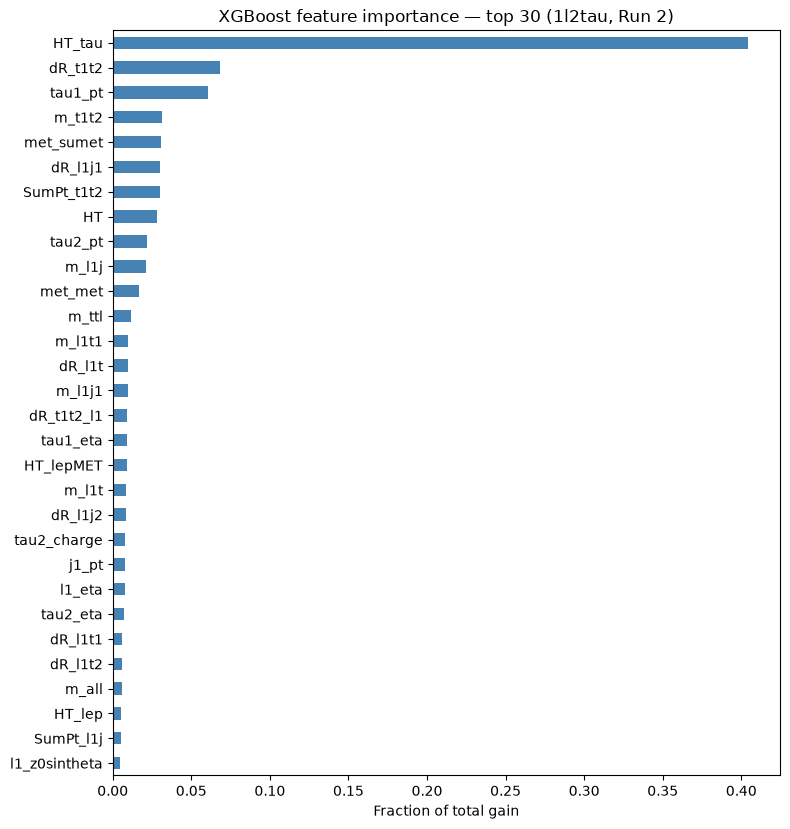

In [12]:
# ---- Baseline XGBoost + feature importance (Run 2) --------------------------
PLOTS_DIR_R2 = BASE_DIR_R2 / "plots"
PLOTS_DIR_R2.mkdir(parents=True, exist_ok=True)

model_r2, auc_train_r2, auc_val_r2 = train_xgb_baseline(
    X_train_r2, y_train_r2, w_train_r2, X_val_r2, y_val_r2, w_val_r2, label="Run2 baseline"
)

imp_r2 = get_importance(model_r2, features_r2)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Run 2):")
print(imp_r2[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_r2['total_gain'] == 0).sum()} / {len(features_r2)}")

plot_importance_bar(imp_r2, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (1l2tau, Run 2)",
                     save_path=PLOTS_DIR_R2 / "Run2BeforeCorrelation.png")


Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2CorrelationTop30.png


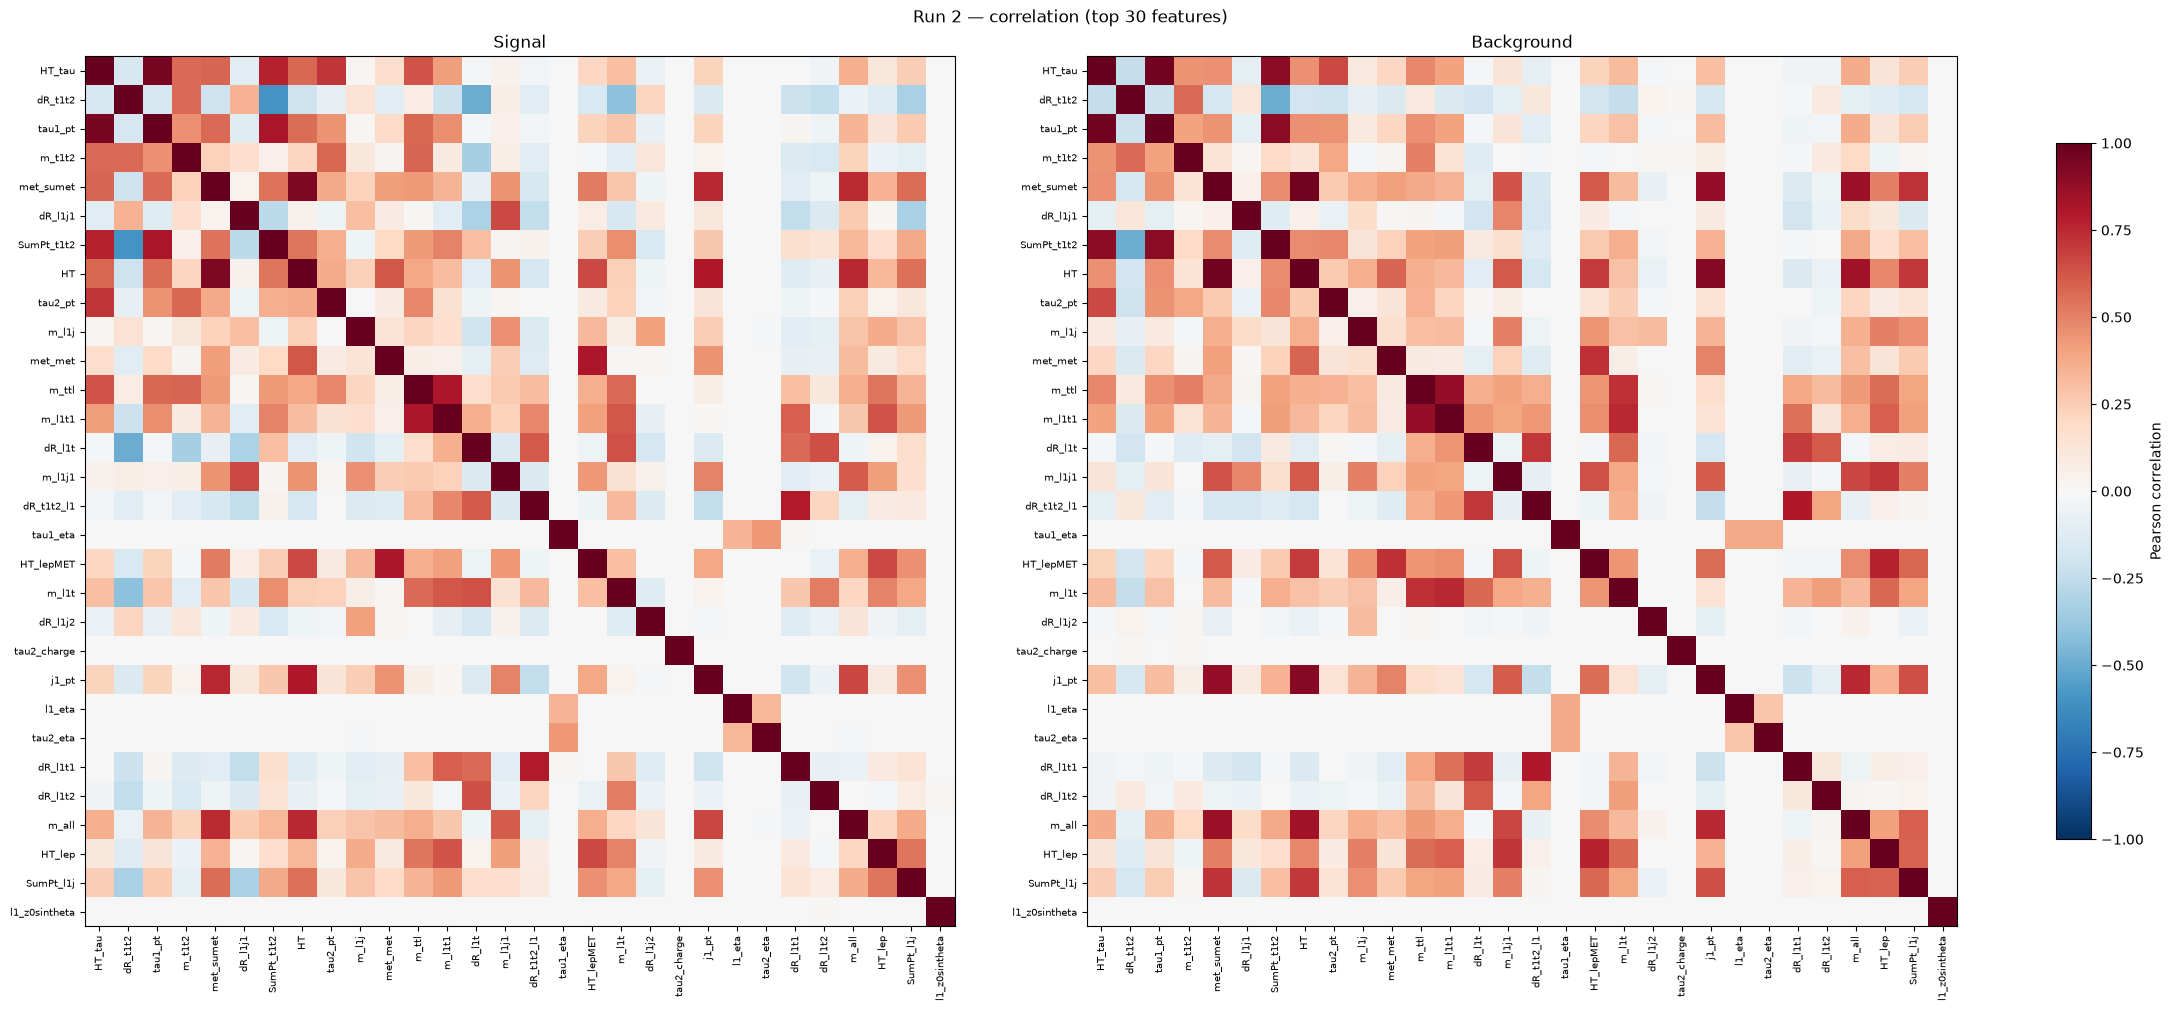

Pairs with |corr| > 0.50 (signal):
HT_tau      tau1_pt      0.946
met_sumet   HT           0.930
tau1_pt     SumPt_t1t2   0.813
met_met     HT_lepMET    0.811
m_ttl       m_l1t1       0.806
HT          j1_pt        0.797
dR_t1t2_l1  dR_l1t1      0.795
HT_tau      SumPt_t1t2   0.769
met_sumet   j1_pt        0.755
HT          m_all        0.751
met_sumet   m_all        0.747
HT_tau      tau2_pt      0.716
j1_pt       m_all        0.665
HT          HT_lepMET    0.664
dR_l1j1     m_l1j1       0.661
HT_lepMET   HT_lep       0.657
dR_l1t      dR_l1t2      0.644
            m_l1t        0.635
m_l1t1      HT_lep       0.631
HT_tau      m_ttl        0.626
HT          met_met      0.622
m_l1t1      m_l1t        0.619
dR_l1t      dR_t1t2_l1   0.616
m_l1j1      m_all        0.606
dR_t1t2     SumPt_t1t2   0.596
m_l1t1      dR_l1t1      0.596
m_t1t2      m_ttl        0.581
HT_tau      met_sumet    0.581
tau1_pt     m_ttl        0.576
m_t1t2      tau2_pt      0.571
HT_tau      HT           0.570
dR_l

In [13]:
# ---- Correlation of the top features (Run 2) --------------------------------
# Pearson correlation among the TOP_N_IMPORTANCE most important features,
# separately for signal and background (correlations genuinely differ between
# the two by physics).

top_feats_r2 = imp_r2.index[:TOP_N_IMPORTANCE].tolist()
corrs_r2 = grouped_correlations(data_r2, top_feats_r2, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_r2[1], corrs_r2[0]], ["Signal", "Background"], top_feats_r2,
    suptitle=f"Run 2 — correlation (top {TOP_N_IMPORTANCE} features)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationTop30.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_r2[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_r2[0]).to_string())


In [14]:
# ---- Correlation-based pruning to a decorrelated top-20 (Run 2) ------------
# Conservative combination: a pair counts as redundant if EITHER regime
# (signal or background) shows near-degeneracy.
corr_max_r2 = corrs_r2[1].abs().combine(corrs_r2[0].abs(), np.maximum)
PRUNED_FEATURES_R2, dropped_r2 = prune_correlated(top_feats_r2, corr_max_r2, CORR_THRESH, N_KEEP)


Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. dR_t1t2
   3. m_t1t2
   4. met_sumet
   5. dR_l1j1
   6. tau2_pt
   7. m_l1j
   8. met_met
   9. m_ttl
  10. dR_l1t
  11. m_l1j1
  12. dR_t1t2_l1
  13. tau1_eta
  14. m_l1t
  15. dR_l1j2
  16. tau2_charge
  17. l1_eta
  18. tau2_eta
  19. dR_l1t2
  20. HT_lep

Dropped 8 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.967)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.895)
  HT              -> redundant with met_sumet       (|corr| = 0.965)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.877)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.811)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.882)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  m_all           -> redundant with met_sumet       (|corr| = 0.859)


[Run2 pruned] signal weight scale factor: 8844.6


[0]	validation_0-logloss:0.65840	validation_0-auc:0.84579
[50]	validation_0-logloss:0.33910	validation_0-auc:0.93111
[100]	validation_0-logloss:0.32828	validation_0-auc:0.93407
[150]	validation_0-logloss:0.32344	validation_0-auc:0.93514
[200]	validation_0-logloss:0.32000	validation_0-auc:0.93536
[250]	validation_0-logloss:0.31755	validation_0-auc:0.93560
[273]	validation_0-logloss:0.31675	validation_0-auc:0.93546
[Run2 pruned] best_iteration=243 | weighted AUC: train=0.9588 val=0.9357

Comparison — full 68 features: val AUC = 0.9436 | pruned 20 features: val AUC = 0.9357
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2AfterCorrelation.png


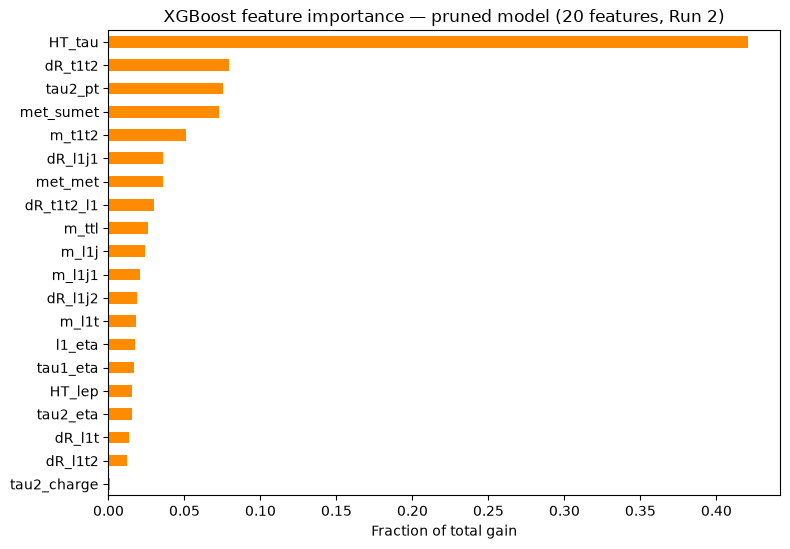

Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2CorrelationPruned.png


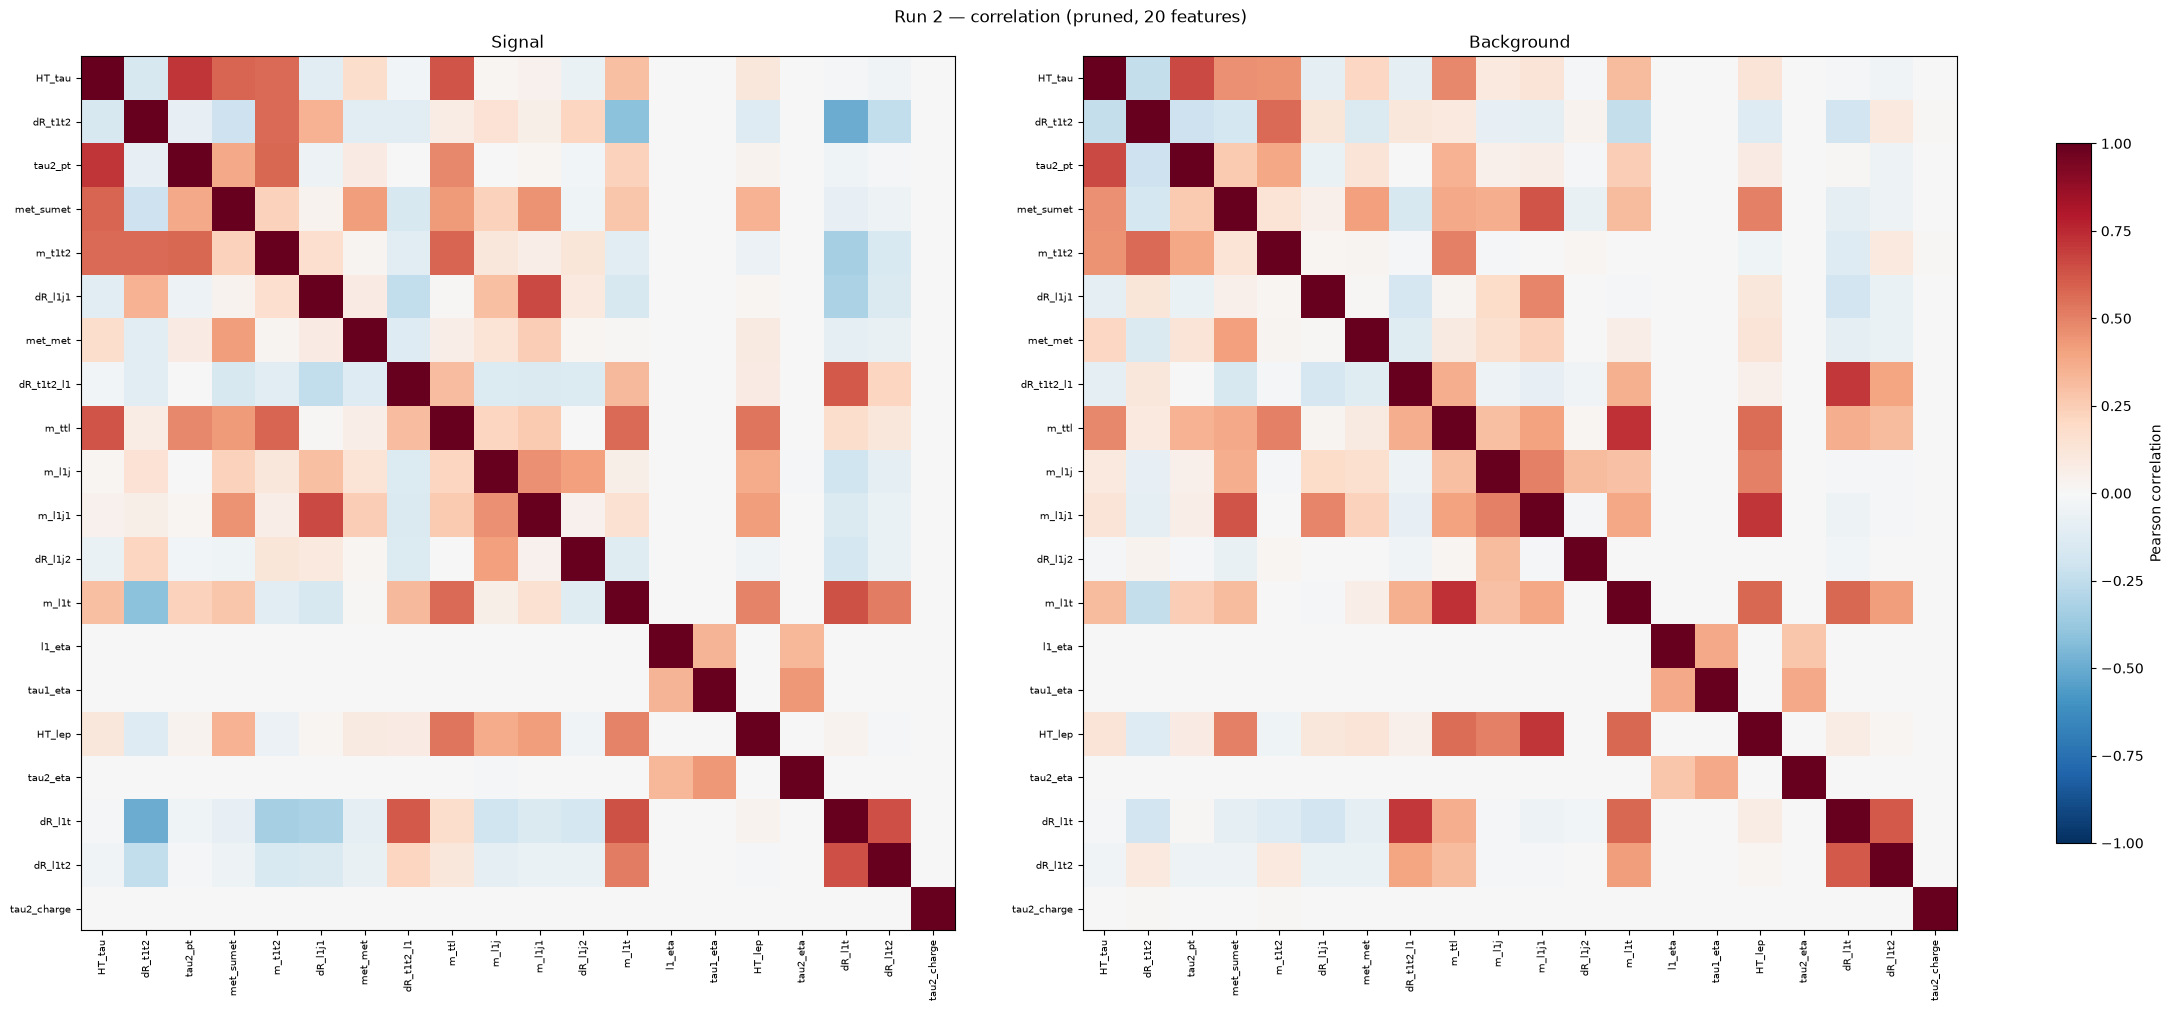

In [15]:
# ---- Retrain on the pruned feature set + re-check correlation (Run 2) ------
model_r2_pruned, auc_train_r2_pruned, auc_val_r2_pruned = train_xgb_baseline(
    X_train_r2[PRUNED_FEATURES_R2], y_train_r2, w_train_r2,
    X_val_r2[PRUNED_FEATURES_R2], y_val_r2, w_val_r2, label="Run2 pruned",
)

imp_r2_pruned = get_importance(model_r2_pruned, PRUNED_FEATURES_R2)
print(f"\nComparison — full {len(features_r2)} features: val AUC = {auc_val_r2:.4f} | "
      f"pruned {len(PRUNED_FEATURES_R2)} features: val AUC = {auc_val_r2_pruned:.4f}")

plot_importance_bar(
    imp_r2_pruned, top_n=len(PRUNED_FEATURES_R2),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_R2)} features, Run 2)",
    color="darkorange",
    save_path=PLOTS_DIR_R2 / "Run2AfterCorrelation.png",
)

pruned_top_feats_r2 = imp_r2_pruned.index.tolist()
pruned_corrs_r2 = grouped_correlations(data_r2, pruned_top_feats_r2, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_r2[1], pruned_corrs_r2[0]], ["Signal", "Background"], pruned_top_feats_r2,
    suptitle=f"Run 2 — correlation (pruned, {len(pruned_top_feats_r2)} features)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationPruned.png",
)


In [16]:
# ---- Optuna hyperparameter search (Run 2) -----------------------------------
# Tune only on the Run-2 training partition, restricted to the decorrelated
# pruned feature set. X_val_r2 is never touched here, so it stays a clean
# holdout for the final tuned model below.

OPTUNA_FEATURES_R2 = PRUNED_FEATURES_R2.copy()

X_opt_r2 = X_train_r2[OPTUNA_FEATURES_R2].reset_index(drop=True)
y_opt_r2 = y_train_r2.reset_index(drop=True).to_numpy()
w_opt_r2 = np.abs(w_train_r2.reset_index(drop=True).to_numpy())

study_r2 = run_optuna_search(
    X_opt_r2, y_opt_r2, w_opt_r2,
    n_trials=N_OPTUNA_TRIALS, n_folds=N_OPTUNA_FOLDS,
    base_n_estimators=800, study_name="xgb_1l2tau_run2",
)


/tmp/ipykernel_12241/175954874.py:74: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[xgb_1l2tau_run2] completed trials: 15
[xgb_1l2tau_run2] best mean CV AUC: 0.93300
[xgb_1l2tau_run2] mean best iteration: 744
[xgb_1l2tau_run2] fold AUCs: [0.9345318859532373, 0.9326510108304294, 0.9318245958742228]
[xgb_1l2tau_run2] best parameters:
    learning_rate: 0.023231731978492907
    max_depth: 8
    min_child_weight: 43.70990468130503
    subsample: 0.9233589392465844
    colsample_bytree: 0.7218455076693483
    gamma: 0.48836057003191935
    reg_alpha: 0.2637333993381525
    reg_lambda: 1.5415527060141936


[Run2 tuned] features=20 trees=744
[Run2 tuned] weighted AUC: train=0.96443 val(holdout)=0.93642 (unweighted val=0.79334, overtrain gap=0.02801)
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2OptunaDiagnostics.png


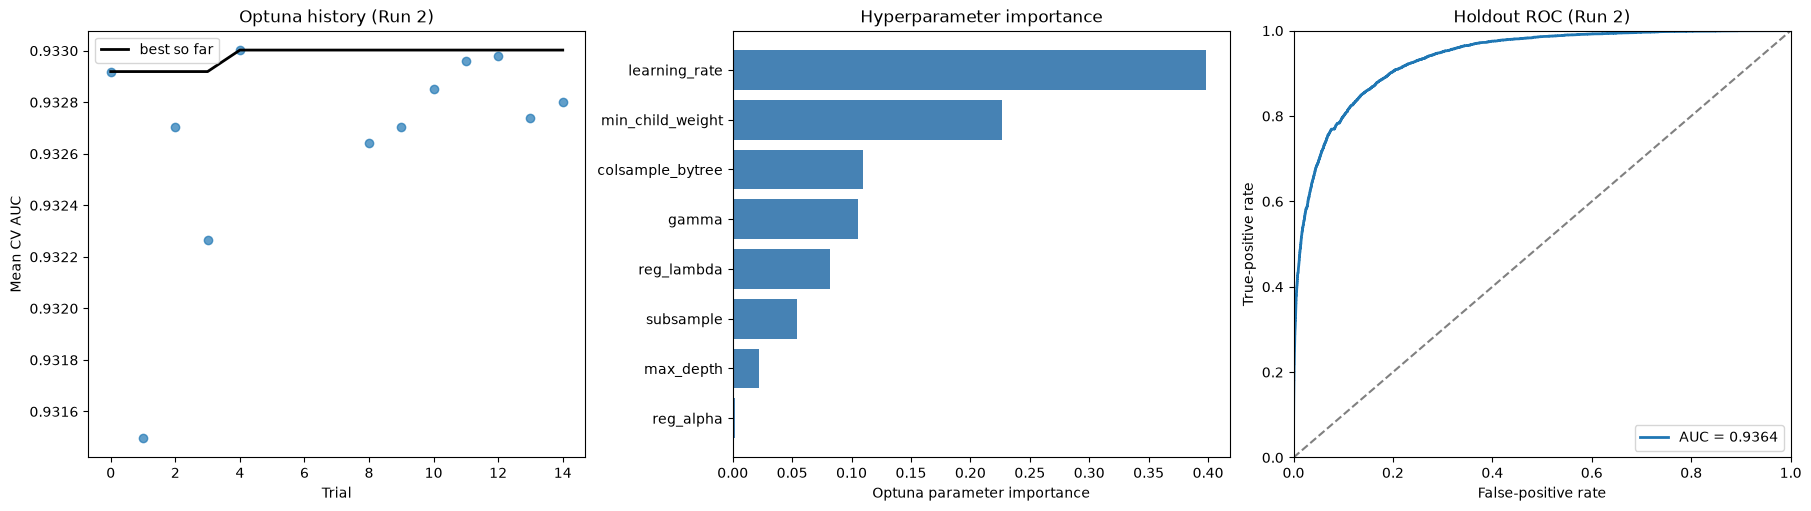

Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2AfterOptuna.png


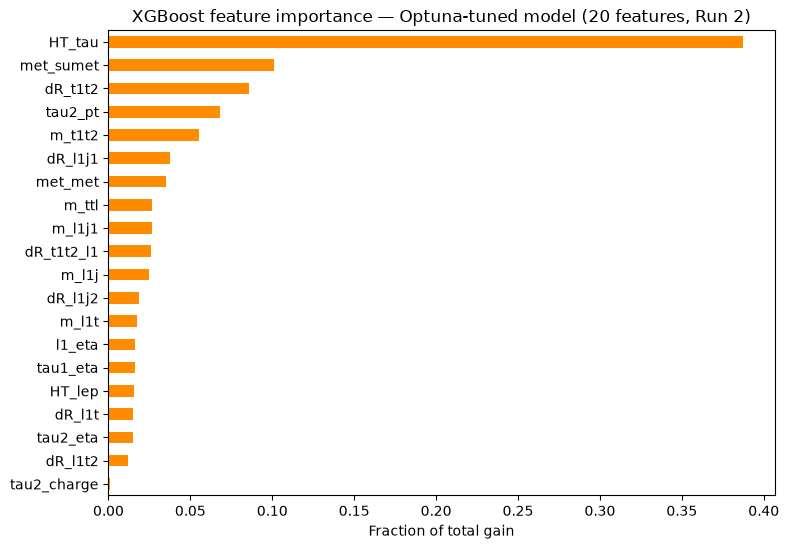

In [17]:
# ---- Final Optuna-tuned model + diagnostics (Run 2) -------------------------
final_model_r2, auc_train_opt_r2, auc_val_opt_r2, pred_val_r2, w_val_abs_r2 = train_final_tuned_model(
    study_r2, X_train_r2[OPTUNA_FEATURES_R2], y_train_r2, w_train_r2,
    X_val_r2[OPTUNA_FEATURES_R2], y_val_r2, w_val_r2, label="Run2 tuned",
)

plot_optuna_diagnostics(study_r2, y_val_r2, pred_val_r2, w_val_abs_r2, auc_val_opt_r2, title_suffix="(Run 2)",
                        save_path=PLOTS_DIR_R2 / "Run2OptunaDiagnostics.png")

final_imp_r2 = get_importance(final_model_r2, OPTUNA_FEATURES_R2)

plot_importance_bar(
    final_imp_r2, top_n=len(OPTUNA_FEATURES_R2),
    title=f"XGBoost feature importance — Optuna-tuned model ({len(OPTUNA_FEATURES_R2)} features, Run 2)",
    color="darkorange",
    save_path=PLOTS_DIR_R2 / "Run2AfterOptuna.png",
)


In [18]:
# ---- Persist the Run-2 final model + feature list ---------------------------
# Used by Section 6 (Run2 vs Run3 domain-shift check) to score events with the
# exact features the signal-vs-background BDT was trained on.
MODEL_PATH_R2 = BASE_DIR_R2 / "final_model_run2.json"
FEATURES_PATH_R2 = BASE_DIR_R2 / "optuna_features_run2.json"

final_model_r2.save_model(MODEL_PATH_R2)
with open(FEATURES_PATH_R2, "w") as f:
    json.dump(OPTUNA_FEATURES_R2, f)

print(f"Saved Run-2 final model                   -> {MODEL_PATH_R2}")
print(f"Saved Run-2 feature list (n={len(OPTUNA_FEATURES_R2)}) -> {FEATURES_PATH_R2}")


Saved Run-2 final model                   -> PPSSP_2026/1l2tau/run2/final_model_run2.json
Saved Run-2 feature list (n=20) -> PPSSP_2026/1l2tau/run2/optuna_features_run2.json


## 4. Run 3 — Solo Track

Identical procedure to Section 3, independently on **Run 3 only** (separate
feature-discovery pass too, in case branches differ slightly between
campaigns).


In [19]:
# ---- Load & clean (Run 3) ---------------------------------------------------
features_r3 = discover_common_features([BASE_DIR_R3])
data_r3 = load_run_data(BASE_DIR_R3, run_label=3, features=features_r3)
data_r3, features_r3 = clean_data(data_r3, features_r3)
data_r3.head()


87 candidate features (common to all 10 processes x 1 run(s) = 10 files, leakage-free)
Run 3 signal_ggF  :   191580 events after preselection
Run 3 signal_VBF  :    13470 events after preselection
Run 3 Diboson     :   628676 events after preselection
Run 3 Zjets       :   157073 events after preselection
Run 3 Wjets       :    39061 events after preselection
Run 3 ttbar       :    40832 events after preselection
Run 3 tops        :   161226 events after preselection
Run 3 SingleH     :    38425 events after preselection
Run 3 Vgamma      :    14295 events after preselection
Run 3 VVV         :    40254 events after preselection
Dropped 19 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_decayMode', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_decayMode', 'tau2_passOR']

68 final features
Total: 

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_eta,tau2_nprong,tau2_phi,tau2_pt,weight,weights,w_phys,label,process,run
0,"295,410.938","225,582.062","139,812.219","27,723.984","97,552.883","58,045.852","74,214.664","66,489.398","56,902.617",3.118,...,1.007,1,-1.305,"23,250.283",0.001,0.040,0.000,1,signal_ggF,3
1,"505,036.750","313,843.375","113,722.625","144,957.328","336,150.688","55,163.426","181,061.453","219,900.609","52,511.066",0.698,...,-2.060,1,-1.316,"24,946.242",0.001,0.042,0.000,1,signal_ggF,3
2,"317,003.156","279,036.906","194,843.141","20,118.156","58,084.398","64,075.617","46,115.941","85,579.805","29,741.354",2.051,...,-1.885,1,-0.555,"26,483.121",0.001,0.049,0.000,1,signal_ggF,3
3,"505,021.500","447,686.375","232,611.266","33,814.699","91,149.812","181,260.422","131,265.047","131,265.047","88,135.117",0.449,...,-0.695,3,-2.463,"50,765.574",0.001,0.033,0.000,1,signal_ggF,3
4,"663,091.812","590,826.000","457,783.594","91,843.344","164,109.219","41,199.023","113,508.242","182,620.422","21,455.129",3.567,...,2.459,1,2.298,"20,445.324",0.001,0.024,0.000,1,signal_ggF,3


In [20]:
# ---- Yields / S over B (Run 3) ----------------------------------------------
yields_r3 = compute_yields(data_r3, BASE_DIR_R3)


   process    N_mc  yield_skim  N_presel      yield  pct_of_bkg  frac_neg
     Wjets   90957  79,013.789     39061 10,898.551      56.274     0.148
     Zjets  339840  31,376.286    157073  4,803.814      24.804     0.148
     ttbar  371546  15,719.117     40832  1,961.856      10.130     0.003
   Diboson 1305959   3,138.175    628676    923.780       4.770     0.061
    Vgamma   36859   2,422.237     14295    433.656       2.239     0.079
      tops 1364404   1,763.957    161226    239.212       1.235     0.359
   SingleH  267413     507.144     38425    101.232       0.523     0.003
       VVV  122940      13.324     40254      4.821       0.025     0.011
signal_ggF  383574       3.831    191580      2.005         NaN     0.062
signal_VBF   30333       0.170     13470      0.076         NaN     0.001

Total background (presel): 19,366.920
Total signal     (presel): 2.081
S/B       = 1.07e-04
S/sqrt(B) = 0.0150


In [21]:
# ---- Train / validation split (Run 3) ---------------------------------------

(X_train_r3, y_train_r3, w_train_r3,
 X_val_r3, y_val_r3, w_val_r3,
 train_df_r3, val_df_r3) = make_train_val_split(data_r3, features_r3)

# ---- Persist the split to ROOT files ----------------------------------------

SPLIT_DIR_R3 = BASE_DIR_R3 / "splits"
SPLIT_DIR_R3.mkdir(parents=True, exist_ok=True)
TRAIN_ROOT_R3 = SPLIT_DIR_R3 / "train.root"
VAL_ROOT_R3 = SPLIT_DIR_R3 / "val.root"

with uproot.recreate(TRAIN_ROOT_R3) as f:
    f["tree"] = train_df_r3.reset_index(drop=True)
with uproot.recreate(VAL_ROOT_R3) as f:
    f["tree"] = val_df_r3.reset_index(drop=True)

print(f"Wrote {len(train_df_r3)} training events   -> {TRAIN_ROOT_R3}")
print(f"Wrote {len(val_df_r3)} validation events -> {VAL_ROOT_R3}")


Train: 1059913 events | signal = 164040 | background = 895873
Val:   264979 events | signal = 41010 | background = 223969
Wrote 1059913 training events   -> PPSSP_2026/1l2tau/run3/splits/train.root
Wrote 264979 validation events -> PPSSP_2026/1l2tau/run3/splits/val.root


[Run3 baseline] signal weight scale factor: 12555.7


[0]	validation_0-logloss:0.64174	validation_0-auc:0.91478
[50]	validation_0-logloss:0.31479	validation_0-auc:0.94118
[100]	validation_0-logloss:0.29801	validation_0-auc:0.94704
[150]	validation_0-logloss:0.29404	validation_0-auc:0.94865
[200]	validation_0-logloss:0.29183	validation_0-auc:0.94973
[250]	validation_0-logloss:0.29022	validation_0-auc:0.95034
[300]	validation_0-logloss:0.28864	validation_0-auc:0.95089
[339]	validation_0-logloss:0.28895	validation_0-auc:0.95089
[Run3 baseline] best_iteration=309 | weighted AUC: train=0.9739 val=0.9509

Top 30 features by total gain (Run 3):
                 total_gain  gain_frac  weight
HT_tau        1,930,886.000      0.425 453.000
tau1_pt         294,636.094      0.065 360.000
dR_t1t2         221,503.422      0.049 650.000
SumPt_t1t2      159,829.297      0.035 534.000
HT              138,250.188      0.030 298.000
tau2_pt         121,256.383      0.027 451.000
m_t1t2          111,124.602      0.024 593.000
dR_l1j1         108,896.328     

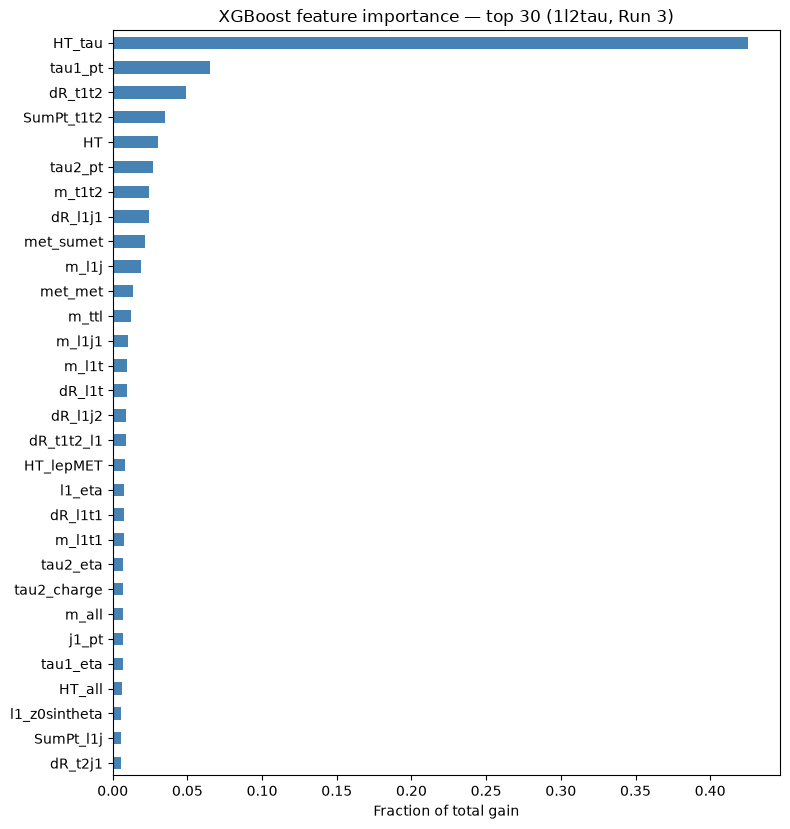

In [22]:
# ---- Baseline XGBoost + feature importance (Run 3) --------------------------
PLOTS_DIR_R3 = BASE_DIR_R3 / "plots"
PLOTS_DIR_R3.mkdir(parents=True, exist_ok=True)

model_r3, auc_train_r3, auc_val_r3 = train_xgb_baseline(
    X_train_r3, y_train_r3, w_train_r3, X_val_r3, y_val_r3, w_val_r3, label="Run3 baseline"
)

imp_r3 = get_importance(model_r3, features_r3)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Run 3):")
print(imp_r3[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_r3['total_gain'] == 0).sum()} / {len(features_r3)}")

plot_importance_bar(imp_r3, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (1l2tau, Run 3)",
                     save_path=PLOTS_DIR_R3 / "Run3BeforeCorrelation.png")


Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3CorrelationTop30.png


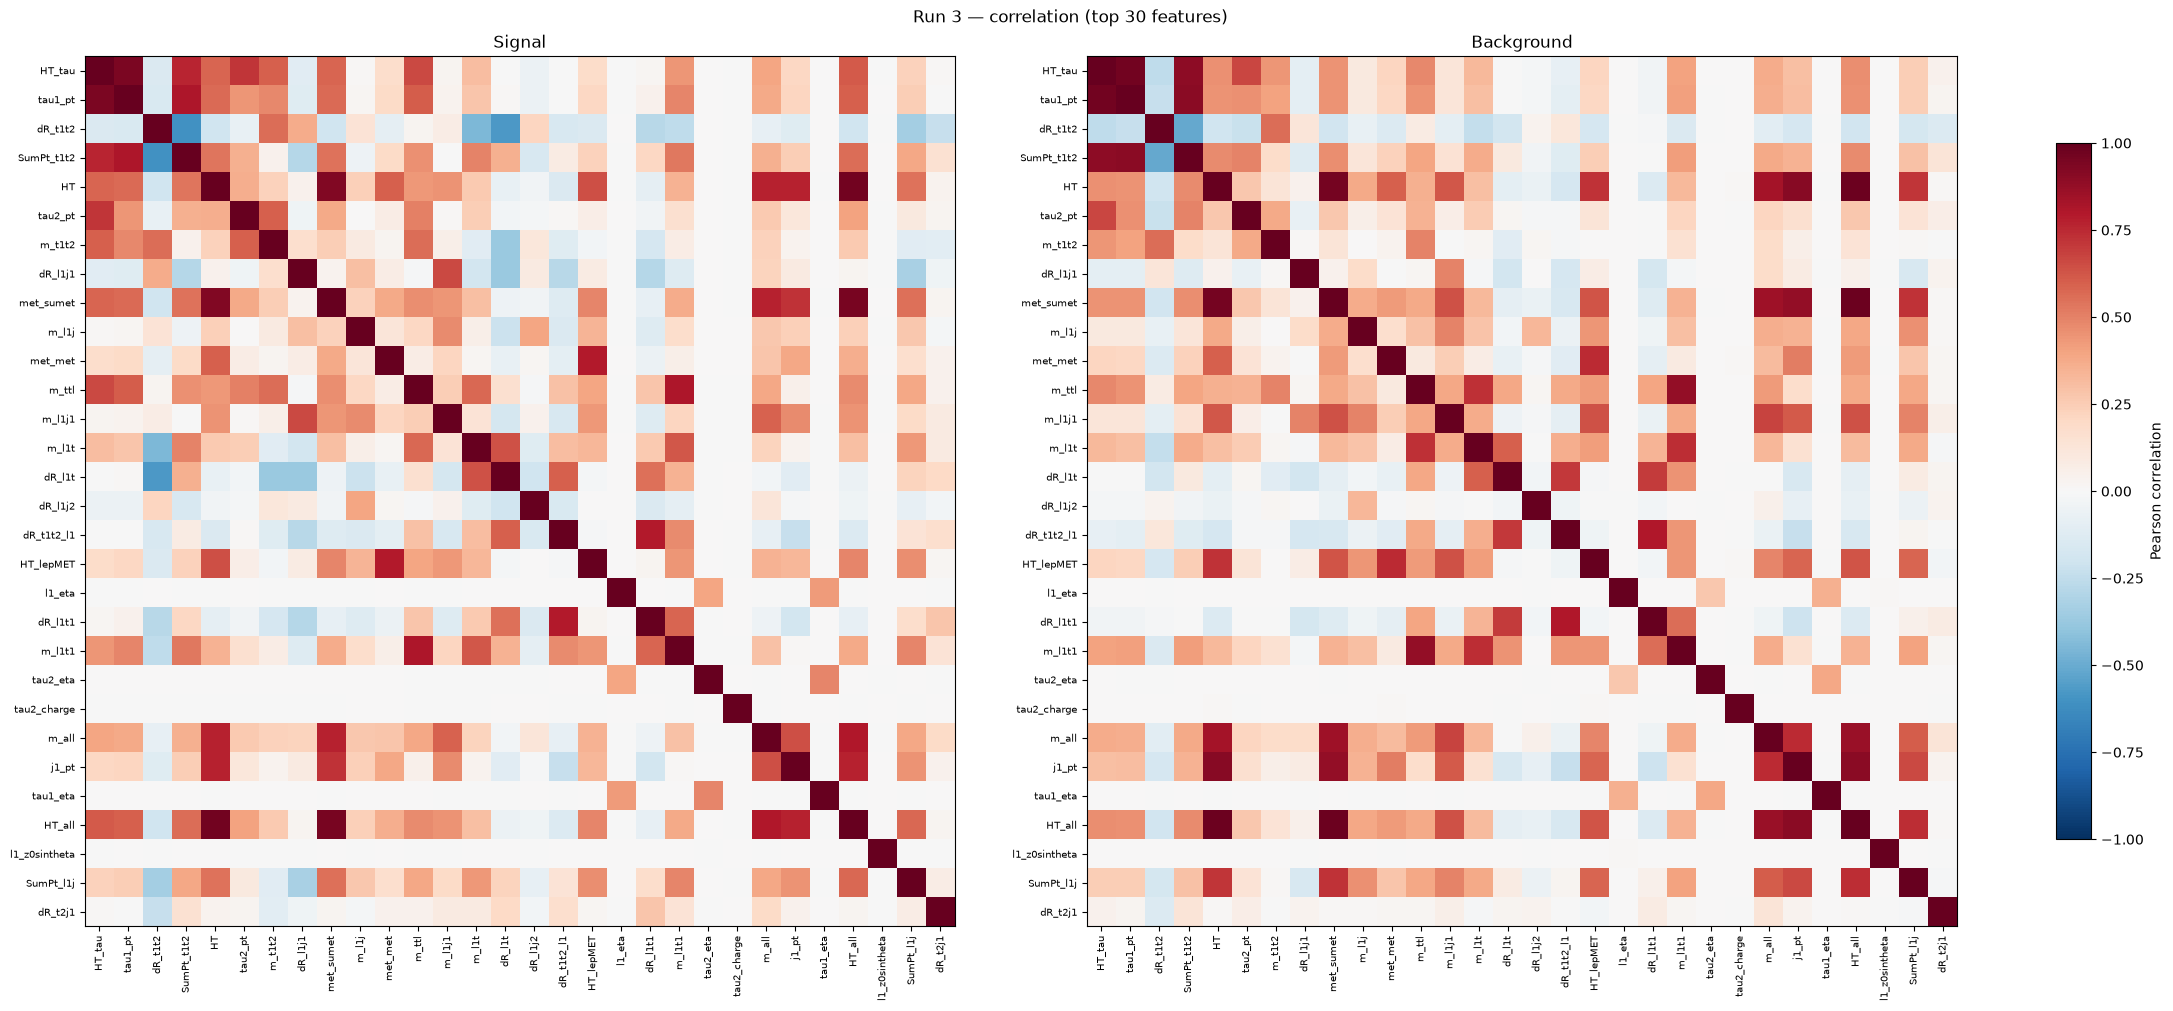

Pairs with |corr| > 0.50 (signal):
HT          HT_all       0.965
met_sumet   HT_all       0.948
HT_tau      tau1_pt      0.944
HT          met_sumet    0.924
m_ttl       m_l1t1       0.810
tau1_pt     SumPt_t1t2   0.809
m_all       HT_all       0.803
dR_t1t2_l1  dR_l1t1      0.794
met_met     HT_lepMET    0.793
HT          m_all        0.771
            j1_pt        0.770
met_sumet   m_all        0.768
j1_pt       HT_all       0.767
HT_tau      SumPt_t1t2   0.764
met_sumet   j1_pt        0.725
HT_tau      tau2_pt      0.711
            m_ttl        0.661
dR_l1j1     m_l1j1       0.661
m_all       j1_pt        0.647
HT          HT_lepMET    0.641
m_l1t       dR_l1t       0.639
            m_l1t1       0.617
HT_tau      HT_all       0.614
tau1_pt     m_ttl        0.608
dR_t1t2     SumPt_t1t2   0.603
HT_tau      m_t1t2       0.597
tau1_pt     HT_all       0.597
dR_l1t      dR_t1t2_l1   0.596
HT          met_met      0.595
tau2_pt     m_t1t2       0.595
m_l1j1      m_all        0.591
HT_t

In [23]:
# ---- Correlation of the top features (Run 3) --------------------------------
top_feats_r3 = imp_r3.index[:TOP_N_IMPORTANCE].tolist()
corrs_r3 = grouped_correlations(data_r3, top_feats_r3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [corrs_r3[1], corrs_r3[0]], ["Signal", "Background"], top_feats_r3,
    suptitle=f"Run 3 — correlation (top {TOP_N_IMPORTANCE} features)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationTop30.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_r3[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_r3[0]).to_string())


In [25]:
# ---- Correlation-based pruning to a decorrelated top-20 (Run 3) ------------
corr_max_r3 = corrs_r3[1].abs().combine(corrs_r3[0].abs(), np.maximum)
PRUNED_FEATURES_R3, dropped_r3 = prune_correlated(top_feats_r3, corr_max_r3, CORR_THRESH, N_KEEP)


Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. dR_t1t2
   3. HT
   4. tau2_pt
   5. m_t1t2
   6. dR_l1j1
   7. m_l1j
   8. met_met
   9. m_ttl
  10. m_l1j1
  11. m_l1t
  12. dR_l1t
  13. dR_l1j2
  14. dR_t1t2_l1
  15. l1_eta
  16. tau2_eta
  17. tau2_charge
  18. tau1_eta
  19. l1_z0sintheta
  20. SumPt_l1j

Dropped 9 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.967)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.898)
  met_sumet       -> redundant with HT              (|corr| = 0.961)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.793)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.880)
  m_all           -> redundant with HT              (|corr| = 0.834)
  j1_pt           -> redundant with HT              (|corr| = 0.911)
  HT_all          -> redundant wi

[Run3 pruned] signal weight scale factor: 12555.7
[0]	validation_0-logloss:0.65385	validation_0-auc:0.86843
[50]	validation_0-logloss:0.32433	validation_0-auc:0.93681
[100]	validation_0-logloss:0.31805	validation_0-auc:0.93932
[150]	validation_0-logloss:0.31782	validation_0-auc:0.94035
[200]	validation_0-logloss:0.31830	validation_0-auc:0.94093


[250]	validation_0-logloss:0.31846	validation_0-auc:0.94124
[300]	validation_0-logloss:0.31946	validation_0-auc:0.94126
[350]	validation_0-logloss:0.31994	validation_0-auc:0.94138
[400]	validation_0-logloss:0.32010	validation_0-auc:0.94148
[418]	validation_0-logloss:0.32057	validation_0-auc:0.94144
[Run3 pruned] best_iteration=388 | weighted AUC: train=0.9683 val=0.9415

Comparison — full 68 features: val AUC = 0.9509 | pruned 20 features: val AUC = 0.9415
Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3AfterCorrelation.png


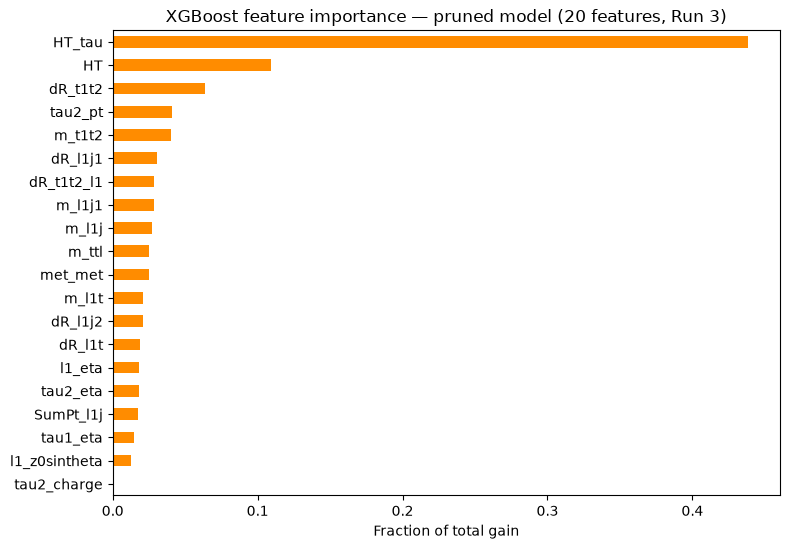

Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3CorrelationPruned.png


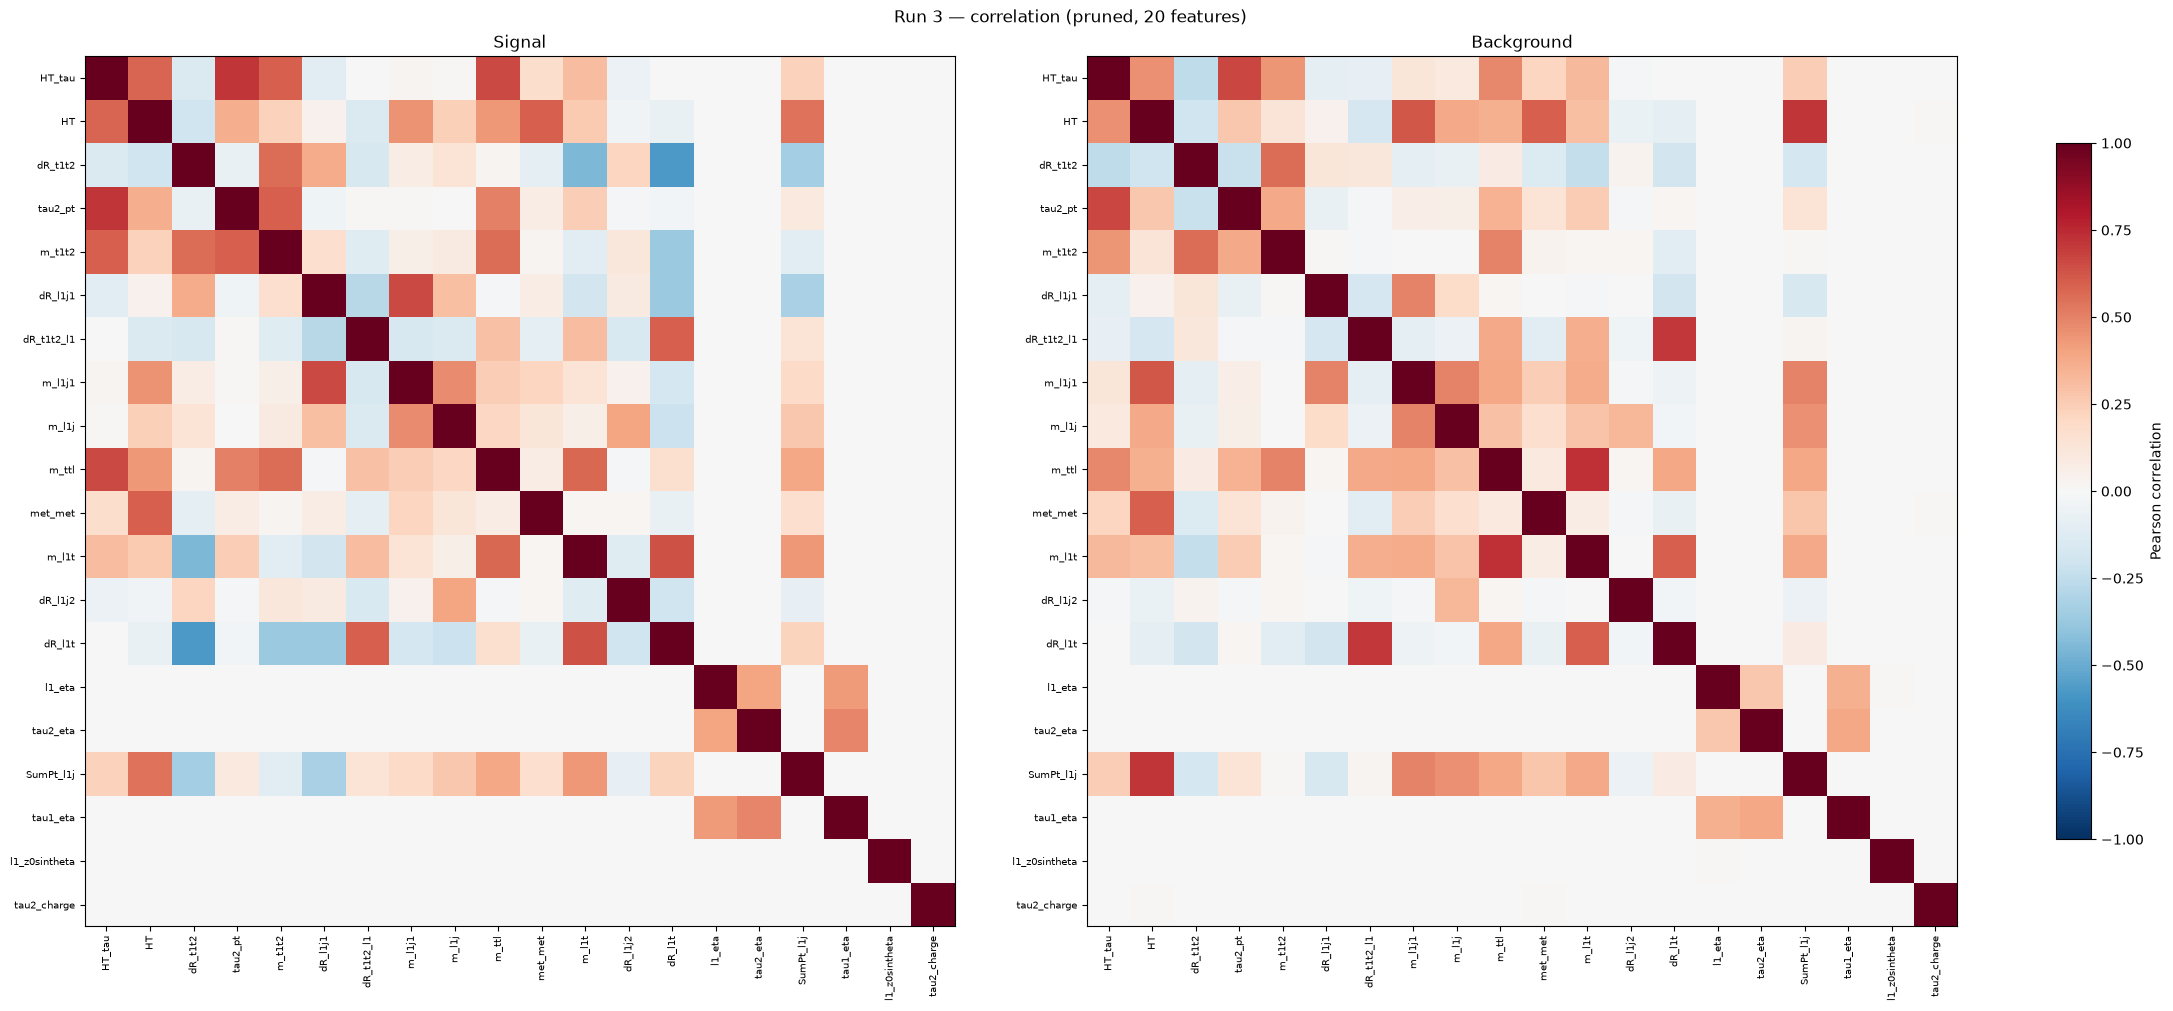

In [26]:
# ---- Retrain on the pruned feature set + re-check correlation (Run 3) ------
model_r3_pruned, auc_train_r3_pruned, auc_val_r3_pruned = train_xgb_baseline(
    X_train_r3[PRUNED_FEATURES_R3], y_train_r3, w_train_r3,
    X_val_r3[PRUNED_FEATURES_R3], y_val_r3, w_val_r3, label="Run3 pruned",
)

imp_r3_pruned = get_importance(model_r3_pruned, PRUNED_FEATURES_R3)
print(f"\nComparison — full {len(features_r3)} features: val AUC = {auc_val_r3:.4f} | "
      f"pruned {len(PRUNED_FEATURES_R3)} features: val AUC = {auc_val_r3_pruned:.4f}")

plot_importance_bar(
    imp_r3_pruned, top_n=len(PRUNED_FEATURES_R3),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_R3)} features, Run 3)",
    color="darkorange",
    save_path=PLOTS_DIR_R3 / "Run3AfterCorrelation.png",
)

pruned_top_feats_r3 = imp_r3_pruned.index.tolist()
pruned_corrs_r3 = grouped_correlations(data_r3, pruned_top_feats_r3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_r3[1], pruned_corrs_r3[0]], ["Signal", "Background"], pruned_top_feats_r3,
    suptitle=f"Run 3 — correlation (pruned, {len(pruned_top_feats_r3)} features)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationPruned.png",
)


In [27]:
# ---- Optuna hyperparameter search (Run 3) -----------------------------------

OPTUNA_FEATURES_R3 = PRUNED_FEATURES_R3.copy()

X_opt_r3 = X_train_r3[OPTUNA_FEATURES_R3].reset_index(drop=True)
y_opt_r3 = y_train_r3.reset_index(drop=True).to_numpy()
w_opt_r3 = np.abs(w_train_r3.reset_index(drop=True).to_numpy())

study_r3 = run_optuna_search(
    X_opt_r3, y_opt_r3, w_opt_r3,
    n_trials=N_OPTUNA_TRIALS, n_folds=N_OPTUNA_FOLDS,
    base_n_estimators=800, study_name="xgb_1l2tau_run3",
)


/tmp/ipykernel_12241/175954874.py:74: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[xgb_1l2tau_run3] completed trials: 15
[xgb_1l2tau_run3] best mean CV AUC: 0.93687
[xgb_1l2tau_run3] mean best iteration: 769
[xgb_1l2tau_run3] fold AUCs: [0.9386452811364366, 0.9327216193468929, 0.9392578159329882]
[xgb_1l2tau_run3] best parameters:
    learning_rate: 0.023231731978492907
    max_depth: 8
    min_child_weight: 43.70990468130503
    subsample: 0.9233589392465844
    colsample_bytree: 0.7218455076693483
    gamma: 0.48836057003191935
    reg_alpha: 0.2637333993381525
    reg_lambda: 1.5415527060141936


[Run3 tuned] features=20 trees=769
[Run3 tuned] weighted AUC: train=0.96807 val(holdout)=0.94246 (unweighted val=0.81547, overtrain gap=0.02561)
Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3OptunaDiagnostics.png


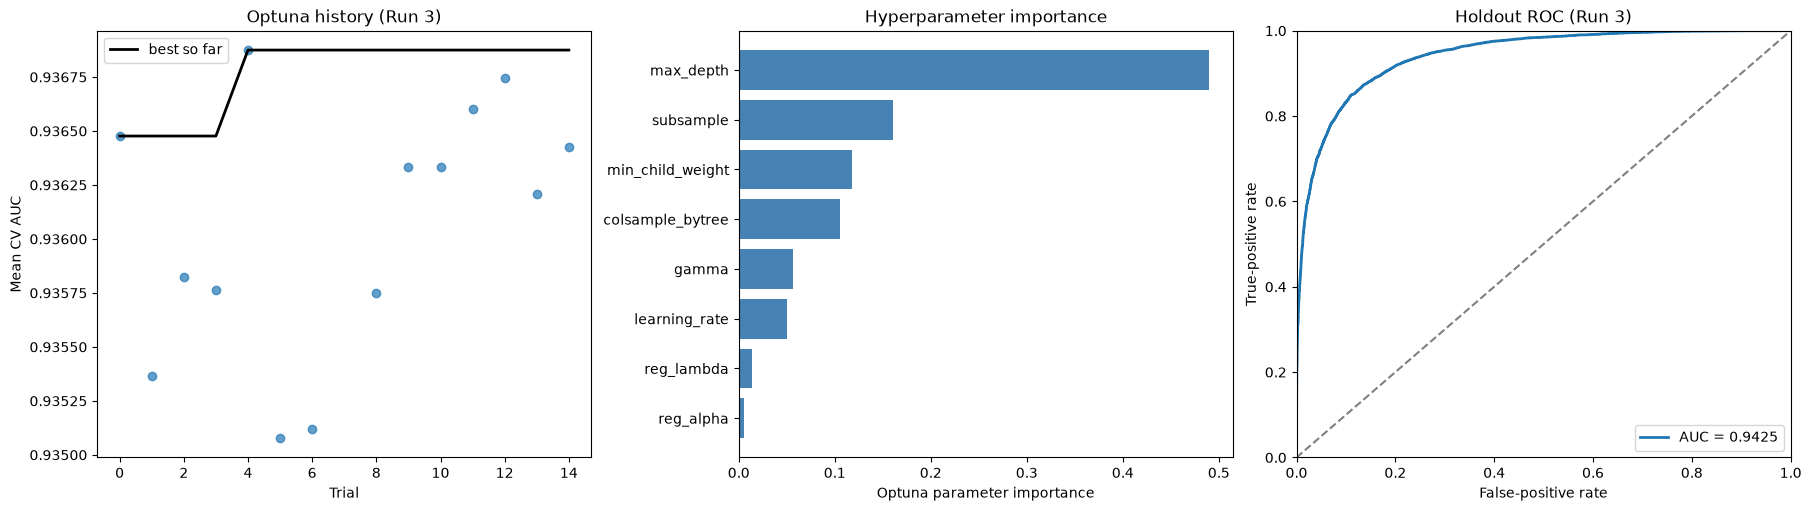

Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3AfterOptuna.png


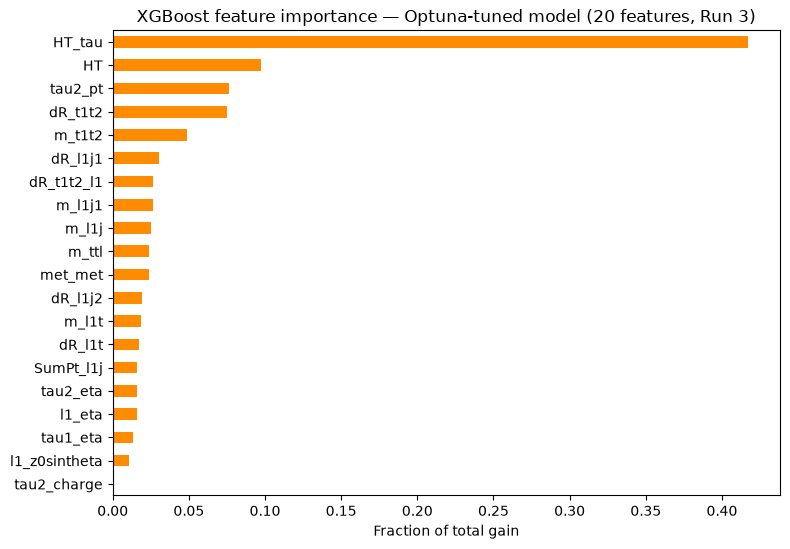

In [28]:
# ---- Final Optuna-tuned model + diagnostics (Run 3) -------------------------

final_model_r3, auc_train_opt_r3, auc_val_opt_r3, pred_val_r3, w_val_abs_r3 = train_final_tuned_model(
    study_r3, X_train_r3[OPTUNA_FEATURES_R3], y_train_r3, w_train_r3,
    X_val_r3[OPTUNA_FEATURES_R3], y_val_r3, w_val_r3, label="Run3 tuned",
)

plot_optuna_diagnostics(study_r3, y_val_r3, pred_val_r3, w_val_abs_r3, auc_val_opt_r3, title_suffix="(Run 3)",
                        save_path=PLOTS_DIR_R3 / "Run3OptunaDiagnostics.png")

final_imp_r3 = get_importance(final_model_r3, OPTUNA_FEATURES_R3)

plot_importance_bar(
    final_imp_r3, top_n=len(OPTUNA_FEATURES_R3),
    title=f"XGBoost feature importance — Optuna-tuned model ({len(OPTUNA_FEATURES_R3)} features, Run 3)",
    color="darkorange",
    save_path=PLOTS_DIR_R3 / "Run3AfterOptuna.png",
)


In [29]:
# ---- Persist the Run-3 final model + feature list ---------------------------
# Symmetric with Run 2's saved artifacts - also used by Section 6.

MODEL_PATH_R3 = BASE_DIR_R3 / "final_model_run3.json"
FEATURES_PATH_R3 = BASE_DIR_R3 / "optuna_features_run3.json"

final_model_r3.save_model(MODEL_PATH_R3)

with open(FEATURES_PATH_R3, "w") as f:
    json.dump(OPTUNA_FEATURES_R3, f)

print(f"Saved Run-3 final model                   -> {MODEL_PATH_R3}")
print(f"Saved Run-3 feature list (n={len(OPTUNA_FEATURES_R3)}) -> {FEATURES_PATH_R3}")


Saved Run-3 final model                   -> PPSSP_2026/1l2tau/run3/final_model_run3.json
Saved Run-3 feature list (n=20) -> PPSSP_2026/1l2tau/run3/optuna_features_run3.json


## 5. Run 2 + Run 3 — Combined Track

Chain (concatenate) **all** backgrounds and **both** signals from **both**
campaigns into a single training sample, then run the same pipeline. This
checks whether the feature-importance ranking learned on the combined sample
differs from the rankings learned separately in Sections 3/4, and gives the
most statistically powerful (most events) version of the BDT.

The feature list here is rebuilt from branches common to **all 20 files**
(10 processes × 2 runs) - a feature dropped in only one run must be dropped
everywhere once the runs are concatenated. An extra `run` column (2 or 3) is
kept as bookkeeping (never a training feature) so the Run2/Run3 mix in
train/val can be checked, and so the split can be stratified on `label` AND
`run` jointly.


In [30]:
# ---- Combined-track output paths --------------------------------------------
BASE_DIR_COMB = Path("PPSSP_2026/1l2tau/combined")
PLOTS_DIR_COMB = BASE_DIR_COMB / "plots"
PLOTS_DIR_COMB.mkdir(parents=True, exist_ok=True)

# ---- Load & clean (Combined Run2 + Run3) ------------------------------------
features_comb = discover_common_features([BASE_DIR_R2, BASE_DIR_R3])
data_comb = pd.concat(
    [
        load_run_data(BASE_DIR_R2, run_label=2, features=features_comb),
        load_run_data(BASE_DIR_R3, run_label=3, features=features_comb),
    ],
    ignore_index=True,
)
data_comb, features_comb = clean_data(data_comb, features_comb)

# Per-run yield breakdown - confirms both runs contribute comparable
# statistics to the chained sample (no run silently dominating the training).
for run_label in (2, 3):
    sub = data_comb[data_comb.run == run_label]
    print(f"Run {run_label}: signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f} | n_events = {len(sub)}")

data_comb.head()


87 candidate features (common to all 10 processes x 2 run(s) = 20 files, leakage-free)
Run 2 signal_ggF  :    67075 events after preselection
Run 2 signal_VBF  :    21639 events after preselection
Run 2 Diboson     :   312600 events after preselection
Run 2 Zjets       :   141863 events after preselection
Run 2 Wjets       :    31272 events after preselection
Run 2 ttbar       :     7335 events after preselection
Run 2 tops        :    62238 events after preselection
Run 2 SingleH     :    11124 events after preselection
Run 2 Vgamma      :    21510 events after preselection
Run 2 VVV         :    14028 events after preselection
Run 3 signal_ggF  :   191580 events after preselection
Run 3 signal_VBF  :    13470 events after preselection
Run 3 Diboson     :   628676 events after preselection
Run 3 Zjets       :   157073 events after preselection
Run 3 Wjets       :    39061 events after preselection
Run 3 ttbar       :    40832 events after preselection
Run 3 tops        :   161226 even

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_eta,tau2_nprong,tau2_phi,tau2_pt,weight,weights,w_phys,label,process,run
0,"486,197.281","437,935.438","350,626.938","42,837.090","91,098.922","44,471.410","77,389.633","91,956.719","12,270.166",2.849,...,0.795,1,-3.045,"22,102.740",0.001,-0.028,-0.000,1,signal_ggF,2
1,"233,307.375","192,779.188","92,852.828","31,019.406","71,547.602","68,906.953","35,689.703","32,890.672","20,957.582",2.693,...,2.437,1,1.528,"30,261.955",0.001,0.055,0.000,1,signal_ggF,2
2,"399,998.125","345,424.469","107,697.430","164,906.188","219,479.844","72,820.844","127,177.953","97,451.047","33,988.949",0.400,...,0.302,1,0.594,"33,664.312",0.001,0.030,0.000,1,signal_ggF,2
3,"344,867.656","249,412.125","165,593.328","21,953.850","117,409.383","61,864.949","36,656.707","111,334.617","18,972.348",2.709,...,1.256,1,0.694,"21,605.848",0.001,0.031,0.000,1,signal_ggF,2
4,"326,392.688","270,753.156","128,916.000","71,331.773","126,971.281","70,505.391","129,401.234","129,401.234","55,308.082",2.955,...,-0.067,1,-1.724,"31,729.717",0.001,0.032,0.000,1,signal_ggF,2


In [ ]:
# ---- Yields / S over B (Combined) -------------------------------------------
# The combined sample is exactly Run2 + Run3 (same processes, same
# preselection), so its yields are simply the per-process sum of the two
# per-run tables already computed in Sections 3/4 - no need to re-read the
# ROOT files a third time.

yields_comb = (
    yields_r2.set_index("process")[["yield", "N_presel"]]
    .add(yields_r3.set_index("process")[["yield", "N_presel"]], fill_value=0)
    .reset_index()
)
is_signal_map = {proc: (label == 1) for proc, (_, label) in FILES.items()}
yields_comb["is_signal"] = yields_comb["process"].map(is_signal_map)

bkg_total_comb = yields_comb.loc[~yields_comb.is_signal, "yield"].sum()
sig_total_comb = yields_comb.loc[yields_comb.is_signal, "yield"].sum()
yields_comb["pct_of_bkg"] = np.where(~yields_comb.is_signal, 100 * yields_comb["yield"] / bkg_total_comb, np.nan)
yields_comb = yields_comb.sort_values(["is_signal", "yield"], ascending=[True, False])

print(yields_comb.to_string(index=False))
print(f"\nTotal background (presel, Run2+Run3): {bkg_total_comb:,.3f}")
print(f"Total signal     (presel, Run2+Run3): {sig_total_comb:,.3f}")
print(f"S/B       = {sig_total_comb/bkg_total_comb:.2e}")
print(f"S/sqrt(B) = {sig_total_comb/np.sqrt(bkg_total_comb):.4f}")


   process      yield  N_presel  is_signal  pct_of_bkg
     Wjets 16,597.206     70333      False      53.827
     Zjets  8,385.972    298936      False      27.197
     ttbar  2,956.109     48167      False       9.587
   Diboson  1,654.147    941276      False       5.365
    Vgamma    710.144     35805      False       2.303
      tops    360.126    223464      False       1.168
   SingleH    161.085     49549      False       0.522
       VVV      9.419     54282      False       0.031
signal_ggF      3.762    258655       True         NaN
signal_VBF      0.143     35109       True         NaN

Total background (presel, Run2+Run3): 30,834.208
Total signal     (presel, Run2+Run3): 3.905
S/B       = 1.27e-04
S/sqrt(B) = 0.0222


In [32]:
# ---- Train / validation split (Combined) ------------------------------------
# Stratify on label AND run jointly (not just label) so the split keeps the
# same Run2/Run3 mix in both partitions.
(X_train_comb, y_train_comb, w_train_comb,
 X_val_comb, y_val_comb, w_val_comb,
 train_df_comb, val_df_comb) = make_train_val_split(data_comb, features_comb, extra_stratify_col="run")


Train: 1612460 events | signal = 235011 | background = 1377449
Val:   403116 events | signal = 58753 | background = 344363
Train run mix: {2: 552547, 3: 1059913}
Val   run mix: {2: 138137, 3: 264979}


[Combined baseline] signal weight scale factor: 10871.5
[0]	validation_0-logloss:0.64283	validation_0-auc:0.90997
[50]	validation_0-logloss:0.32580	validation_0-auc:0.93690
[100]	validation_0-logloss:0.30696	validation_0-auc:0.94354
[150]	validation_0-logloss:0.30072	validation_0-auc:0.94554
[200]	validation_0-logloss:0.29699	validation_0-auc:0.94677
[250]	validation_0-logloss:0.29581	validation_0-auc:0.94719
[300]	validation_0-logloss:0.29465	validation_0-auc:0.94756
[350]	validation_0-logloss:0.29293	validation_0-auc:0.94772
[400]	validation_0-logloss:0.29279	validation_0-auc:0.94793
[450]	validation_0-logloss:0.29177	validation_0-auc:0.94797
[499]	validation_0-logloss:0.29084	validation_0-auc:0.94801
[Combined baseline] best_iteration=486 | weighted AUC: train=0.9726 val=0.9480

Top 30 features by total gain (Combined Run2+Run3):
               total_gain  gain_frac  weight
HT_tau      2,859,596.250      0.423 595.000
tau1_pt       408,057.375      0.060 557.000
dR_t1t2       383,24

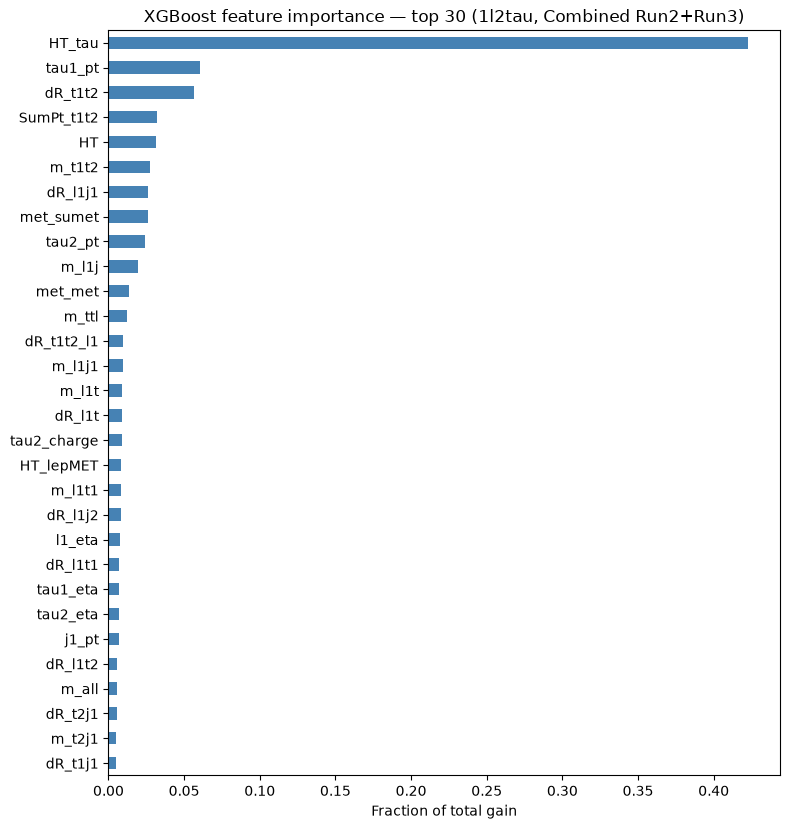

In [33]:
# ---- Baseline XGBoost + feature importance (Combined) -----------------------
model_comb, auc_train_comb, auc_val_comb = train_xgb_baseline(
    X_train_comb, y_train_comb, w_train_comb, X_val_comb, y_val_comb, w_val_comb, label="Combined baseline"
)

imp_comb = get_importance(model_comb, features_comb)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Combined Run2+Run3):")
print(imp_comb[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_comb['total_gain'] == 0).sum()} / {len(features_comb)}")

plot_importance_bar(imp_comb, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (1l2tau, Combined Run2+Run3)",
                     save_path=PLOTS_DIR_COMB / "CombinedBeforeCorrelation.png")


Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedCorrelationTop30.png


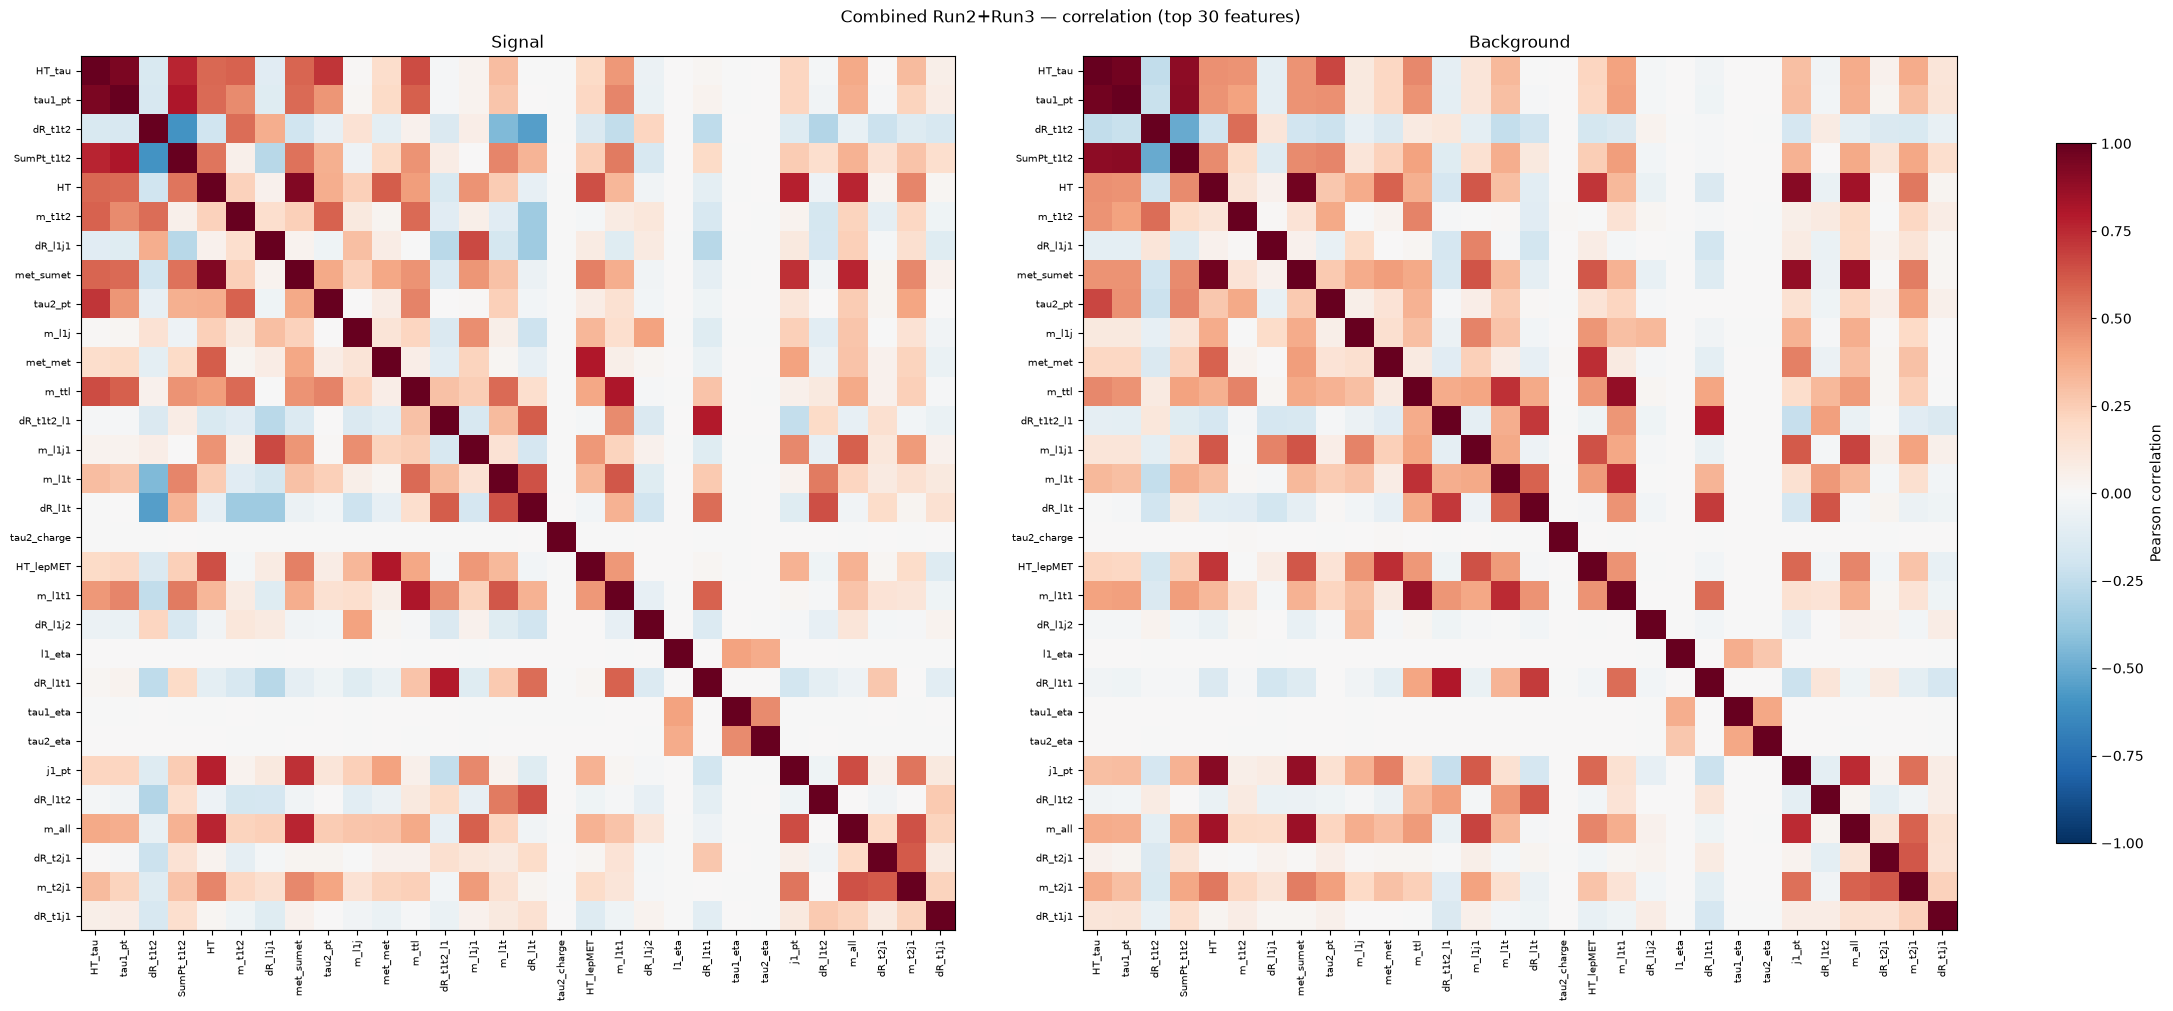

Pairs with |corr| > 0.50 (signal):
HT_tau      tau1_pt      0.945
HT          met_sumet    0.926
tau1_pt     SumPt_t1t2   0.810
m_ttl       m_l1t1       0.808
met_met     HT_lepMET    0.798
dR_t1t2_l1  dR_l1t1      0.794
HT          j1_pt        0.778
HT_tau      SumPt_t1t2   0.765
HT          m_all        0.762
met_sumet   m_all        0.759
            j1_pt        0.734
HT_tau      tau2_pt      0.713
dR_l1j1     m_l1j1       0.661
j1_pt       m_all        0.653
HT_tau      m_ttl        0.650
HT          HT_lepMET    0.648
dR_l1t      dR_l1t2      0.646
m_l1t       dR_l1t       0.638
m_all       m_t2j1       0.634
m_l1t       m_l1t1       0.618
dR_t2j1     m_t2j1       0.612
HT          met_met      0.603
dR_t1t2_l1  dR_l1t       0.602
dR_t1t2     SumPt_t1t2   0.601
tau1_pt     m_ttl        0.598
m_l1j1      m_all        0.597
HT_tau      m_t1t2       0.587
m_t1t2      tau2_pt      0.587
m_l1t1      dR_l1t1      0.587
HT_tau      met_sumet    0.583
            HT           0.577
m_tt

In [34]:
# ---- Correlation of the top features + pruning (Combined) -------------------
top_feats_comb = imp_comb.index[:TOP_N_IMPORTANCE].tolist()
corrs_comb = grouped_correlations(data_comb, top_feats_comb, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [corrs_comb[1], corrs_comb[0]], ["Signal", "Background"], top_feats_comb,
    suptitle=f"Combined Run2+Run3 — correlation (top {TOP_N_IMPORTANCE} features)",
    save_path=PLOTS_DIR_COMB / "CombinedCorrelationTop30.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_comb[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_comb[0]).to_string())

corr_max_comb = corrs_comb[1].abs().combine(corrs_comb[0].abs(), np.maximum)
PRUNED_FEATURES_COMB, dropped_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, N_KEEP)


[Combined pruned] signal weight scale factor: 10871.5
[0]	validation_0-logloss:0.65021	validation_0-auc:0.88219
[50]	validation_0-logloss:0.33190	validation_0-auc:0.93316
[100]	validation_0-logloss:0.32507	validation_0-auc:0.93578
[150]	validation_0-logloss:0.32149	validation_0-auc:0.93725
[200]	validation_0-logloss:0.31990	validation_0-auc:0.93778
[250]	validation_0-logloss:0.31891	validation_0-auc:0.93828
[300]	validation_0-logloss:0.31954	validation_0-auc:0.93834
[350]	validation_0-logloss:0.31847	validation_0-auc:0.93841
[353]	validation_0-logloss:0.31851	validation_0-auc:0.93839
[Combined pruned] best_iteration=323 | weighted AUC: train=0.9568 val=0.9384

Comparison — full 68 features: val AUC = 0.9480 | pruned 20 features: val AUC = 0.9384
Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedAfterCorrelation.png


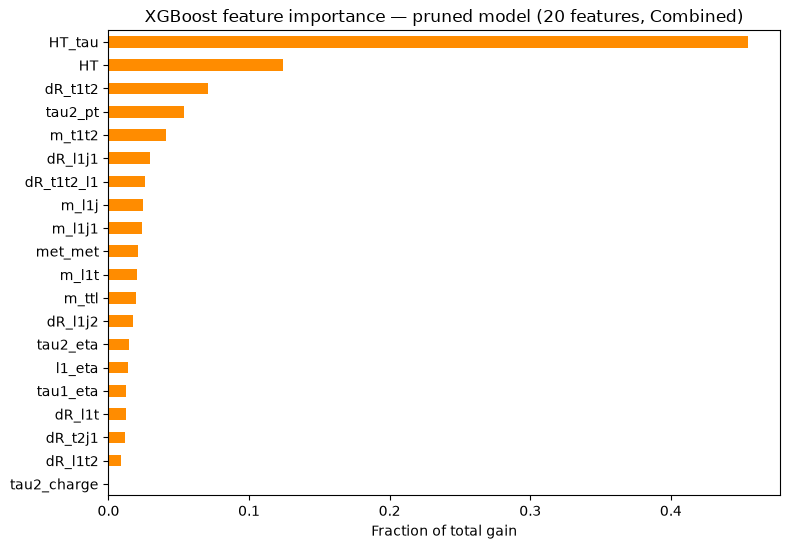

In [35]:
# ---- Retrain on the pruned feature set + re-check correlation (Combined) ---
model_comb_pruned, auc_train_comb_pruned, auc_val_comb_pruned = train_xgb_baseline(
    X_train_comb[PRUNED_FEATURES_COMB], y_train_comb, w_train_comb,
    X_val_comb[PRUNED_FEATURES_COMB], y_val_comb, w_val_comb, label="Combined pruned",
)

imp_comb_pruned = get_importance(model_comb_pruned, PRUNED_FEATURES_COMB)
print(f"\nComparison — full {len(features_comb)} features: val AUC = {auc_val_comb:.4f} | "
      f"pruned {len(PRUNED_FEATURES_COMB)} features: val AUC = {auc_val_comb_pruned:.4f}")

plot_importance_bar(
    imp_comb_pruned, top_n=len(PRUNED_FEATURES_COMB),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_COMB)} features, Combined)",
    color="darkorange",
    save_path=PLOTS_DIR_COMB / "CombinedAfterCorrelation.png",
)


### Top-15 further cut

Take the top 15 features from the pruned model's own ranking and retrain once
more, to see how much validation AUC is lost going from 20 → 15 features.


In [36]:
# ---- Retrain using only the top 15 features (Combined) ----------------------
TOP_15 = 15
TOP15_FEATURES_COMB = imp_comb_pruned.index[:TOP_15].tolist()
print(f"Top {TOP_15} features kept (from the 20-feature pruned model's own ranking):")
for i, feat in enumerate(TOP15_FEATURES_COMB, 1):
    print(f"  {i:2d}. {feat}")

model_comb_top15, auc_train_comb_top15, auc_val_comb_top15 = train_xgb_baseline(
    X_train_comb[TOP15_FEATURES_COMB], y_train_comb, w_train_comb,
    X_val_comb[TOP15_FEATURES_COMB], y_val_comb, w_val_comb, label="Combined top-15",
)

print(f"\nWeighted AUC (top {TOP_15} features):  val = {auc_val_comb_top15:.4f}")
print(f"Weighted AUC (pruned {len(PRUNED_FEATURES_COMB)} features): val = {auc_val_comb_pruned:.4f}")
print(f"Weighted AUC (full {len(features_comb)} features):    val = {auc_val_comb:.4f}")


Top 15 features kept (from the 20-feature pruned model's own ranking):
   1. HT_tau
   2. HT
   3. dR_t1t2
   4. tau2_pt
   5. m_t1t2
   6. dR_l1j1
   7. dR_t1t2_l1
   8. m_l1j
   9. m_l1j1
  10. met_met
  11. m_l1t
  12. m_ttl
  13. dR_l1j2
  14. tau2_eta
  15. l1_eta
[Combined top-15] signal weight scale factor: 10871.5
[0]	validation_0-logloss:0.64428	validation_0-auc:0.90612
[50]	validation_0-logloss:0.33457	validation_0-auc:0.93179
[100]	validation_0-logloss:0.32758	validation_0-auc:0.93414
[150]	validation_0-logloss:0.32561	validation_0-auc:0.93500
[200]	validation_0-logloss:0.32387	validation_0-auc:0.93559
[250]	validation_0-logloss:0.32476	validation_0-auc:0.93576
[260]	validation_0-logloss:0.32473	validation_0-auc:0.93576
[Combined top-15] best_iteration=230 | weighted AUC: train=0.9505 val=0.9358

Weighted AUC (top 15 features):  val = 0.9358
Weighted AUC (pruned 20 features): val = 0.9384
Weighted AUC (full 68 features):    val = 0.9480


Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedModelComparison.png


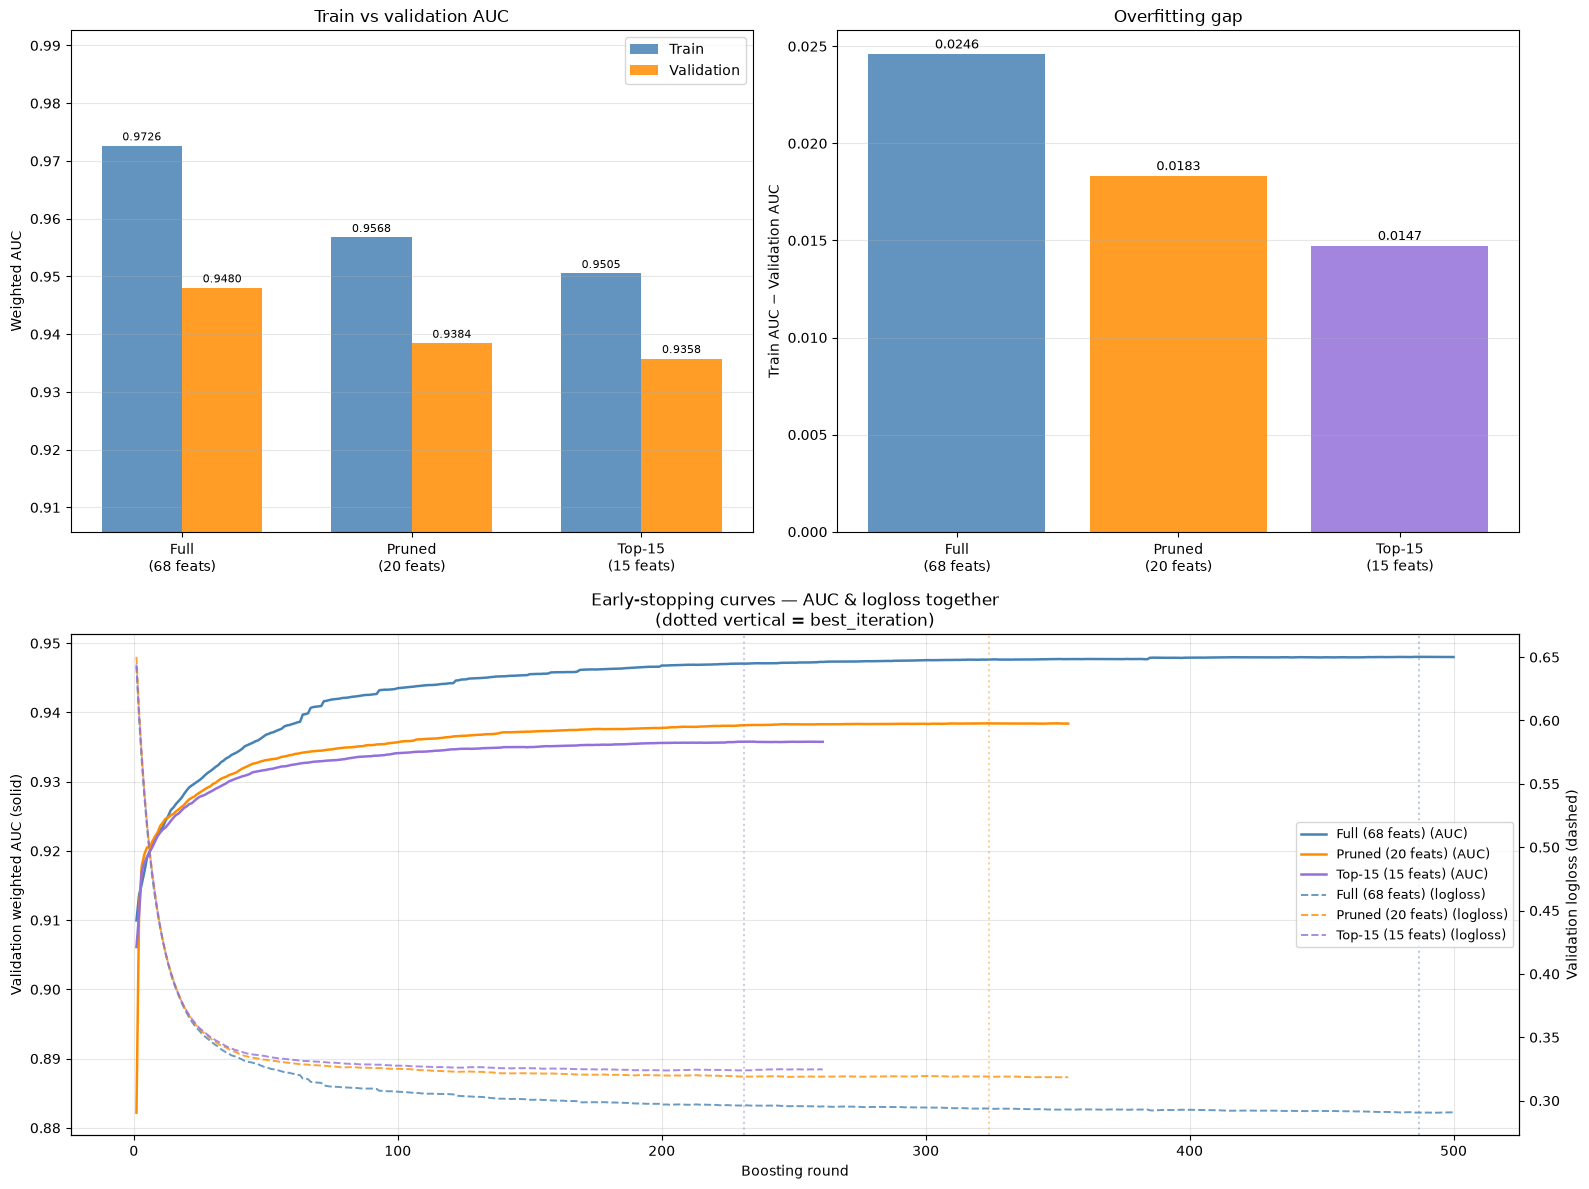

Model                #Features   Train AUC     Val AUC       Gap
Full                        68      0.9726      0.9480    0.0246
Pruned                      20      0.9568      0.9384    0.0183
Top-15                      15      0.9505      0.9358    0.0147


In [37]:
# ---- Model comparison — AUC & training curves (full vs pruned vs top-15) ---
model_names_comb = [f"Full\n({len(features_comb)} feats)", f"Pruned\n({len(PRUNED_FEATURES_COMB)} feats)",
                     f"Top-15\n({len(TOP15_FEATURES_COMB)} feats)"]
colors_comb = ["steelblue", "darkorange", "mediumpurple"]
train_aucs_comb = [auc_train_comb, auc_train_comb_pruned, auc_train_comb_top15]
val_aucs_comb = [auc_val_comb, auc_val_comb_pruned, auc_val_comb_top15]
models_fitted_comb = [model_comb, model_comb_pruned, model_comb_top15]

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)
ax_bars = fig.add_subplot(gs[0, 0])
ax_gap = fig.add_subplot(gs[0, 1])
ax_auc = fig.add_subplot(gs[1, :])   # wide combined panel, spans both columns

# --- Panel (0,0): train vs validation AUC, grouped bars --------------------
x = np.arange(len(model_names_comb))
width = 0.35
b1 = ax_bars.bar(x - width/2, train_aucs_comb, width, label="Train", color="steelblue", alpha=0.85)
b2 = ax_bars.bar(x + width/2, val_aucs_comb, width, label="Validation", color="darkorange", alpha=0.85)
for bars in (b1, b2):
    ax_bars.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
ax_bars.set_xticks(x)
ax_bars.set_xticklabels(model_names_comb)
ax_bars.set_ylabel("Weighted AUC")
ax_bars.set_ylim(min(val_aucs_comb) - 0.03, max(train_aucs_comb) + 0.02)
ax_bars.set_title("Train vs validation AUC")
ax_bars.legend()
ax_bars.grid(axis="y", alpha=0.3)

# --- Panel (0,1): overfitting gap (train - validation AUC) -----------------
gaps_comb = [t - v for t, v in zip(train_aucs_comb, val_aucs_comb)]
bars = ax_gap.bar(model_names_comb, gaps_comb, color=colors_comb, alpha=0.85)
ax_gap.bar_label(bars, fmt="%.4f", fontsize=9, padding=2)
ax_gap.set_ylabel("Train AUC − Validation AUC")
ax_gap.set_title("Overfitting gap")
ax_gap.grid(axis="y", alpha=0.3)

# --- Panel (1, :): validation AUC + logloss vs boosting round --------------
ax_loss = ax_auc.twinx()
for name, mdl, color in zip(model_names_comb, models_fitted_comb, colors_comb):
    label = name.replace("\n", " ")
    auc_curve = mdl.evals_result()["validation_0"]["auc"]
    loss_curve = mdl.evals_result()["validation_0"]["logloss"]
    rounds = np.arange(1, len(auc_curve) + 1)
    ax_auc.plot(rounds, auc_curve, color=color, linestyle="-", linewidth=1.8, label=f"{label} (AUC)")
    ax_loss.plot(rounds, loss_curve, color=color, linestyle="--", linewidth=1.4, alpha=0.8, label=f"{label} (logloss)")
    ax_auc.axvline(mdl.best_iteration + 1, color=color, linestyle=":", alpha=0.4)

ax_auc.set_xlabel("Boosting round")
ax_auc.set_ylabel("Validation weighted AUC (solid)")
ax_loss.set_ylabel("Validation logloss (dashed)")
ax_auc.set_title("Early-stopping curves — AUC & logloss together\n(dotted vertical = best_iteration)")
ax_auc.grid(alpha=0.3)

lines_auc, labels_auc = ax_auc.get_legend_handles_labels()
lines_loss, labels_loss = ax_loss.get_legend_handles_labels()
ax_auc.legend(lines_auc + lines_loss, labels_auc + labels_loss, fontsize=9, loc="center right")

plt.tight_layout()
fig.savefig(PLOTS_DIR_COMB / "CombinedModelComparison.png", dpi=150)
print(f"Saved plot -> {PLOTS_DIR_COMB / 'CombinedModelComparison.png'}")
plt.show()

print(f"{'Model':<20s}{'#Features':>10s}{'Train AUC':>12s}{'Val AUC':>12s}{'Gap':>10s}")
for name, feats, tr, va in zip(["Full", "Pruned", "Top-15"],
                                [features_comb, PRUNED_FEATURES_COMB, TOP15_FEATURES_COMB],
                                train_aucs_comb, val_aucs_comb):
    print(f"{name:<20s}{len(feats):>10d}{tr:>12.4f}{va:>12.4f}{tr - va:>10.4f}")


### Optuna tuning (Combined)

In [ ]:
# ---- Optuna hyperparameter search (Combined) --------------------------------
OPTUNA_FEATURES_COMB = PRUNED_FEATURES_COMB.copy()

X_opt_comb = X_train_comb[OPTUNA_FEATURES_COMB].reset_index(drop=True)
y_opt_comb = y_train_comb.reset_index(drop=True).to_numpy()
w_opt_comb = np.abs(w_train_comb.reset_index(drop=True).to_numpy())

study_comb = run_optuna_search(
    X_opt_comb, y_opt_comb, w_opt_comb,
    n_trials=N_OPTUNA_TRIALS, n_folds=N_OPTUNA_FOLDS,
    base_n_estimators=800, study_name="xgb_1l2tau_combined",
)


/tmp/ipykernel_12241/175954874.py:74: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
# ---- Final Optuna-tuned model + diagnostics (Combined) ----------------------
final_model_comb, auc_train_opt_comb, auc_val_opt_comb, pred_val_comb, w_val_abs_comb = train_final_tuned_model(
    study_comb, X_train_comb[OPTUNA_FEATURES_COMB], y_train_comb, w_train_comb,
    X_val_comb[OPTUNA_FEATURES_COMB], y_val_comb, w_val_comb, label="Combined tuned",
)

plot_optuna_diagnostics(study_comb, y_val_comb, pred_val_comb, w_val_abs_comb, auc_val_opt_comb, title_suffix="(Combined)",
                        save_path=PLOTS_DIR_COMB / "CombinedOptunaDiagnostics.png")

final_imp_comb = get_importance(final_model_comb, OPTUNA_FEATURES_COMB)
plot_importance_bar(
    final_imp_comb, top_n=len(OPTUNA_FEATURES_COMB),
    title=f"XGBoost feature importance — Optuna-tuned model ({len(OPTUNA_FEATURES_COMB)} features, Combined)",
    color="darkorange",
    save_path=PLOTS_DIR_COMB / "CombinedAfterOptuna.png",
)


In [ ]:
# ---- Persist the Combined final model + feature list -------------------------
# BASE_DIR_COMB was already defined at the start of Section 5.
MODEL_PATH_COMB = BASE_DIR_COMB / "final_model_combined.json"
FEATURES_PATH_COMB = BASE_DIR_COMB / "optuna_features_combined.json"

final_model_comb.save_model(MODEL_PATH_COMB)
with open(FEATURES_PATH_COMB, "w") as f:
    json.dump(OPTUNA_FEATURES_COMB, f)

print(f"Saved Combined final model                   -> {MODEL_PATH_COMB}")
print(f"Saved Combined feature list (n={len(OPTUNA_FEATURES_COMB)}) -> {FEATURES_PATH_COMB}")


### Did the ranking change? Run 2-only vs Run 3-only vs Combined

Compare where each of the Combined track's tuned features lands in the Run
2-only and Run 3-only tuned rankings (Sections 3/4) — a large rank shift for
a feature would be a warning sign that it behaves inconsistently between
campaigns.


In [ ]:
# ---- Rank comparison across the three tuned tracks --------------------------
combined_rank = {feat: i + 1 for i, feat in enumerate(final_imp_comb.index)}
run2_rank = {feat: i + 1 for i, feat in enumerate(final_imp_r2.index)}
run3_rank = {feat: i + 1 for i, feat in enumerate(final_imp_r3.index)}

rows = []
for feat in OPTUNA_FEATURES_COMB:
    rows.append({
        "feature": feat,
        "combined_rank": combined_rank.get(feat),
        "run2_only_rank": run2_rank.get(feat, "not kept"),
        "run3_only_rank": run3_rank.get(feat, "not kept"),
    })
rank_compare = pd.DataFrame(rows).set_index("feature")
print(f"Combined-track top-{len(OPTUNA_FEATURES_COMB)} features vs. their rank in the "
      f"Run2-only / Run3-only tuned models:")
print(rank_compare.to_string())

# Simple rank-shift summary (only where the feature survived pruning in both
# single-run tracks too)
comparable = rank_compare[
    pd.to_numeric(rank_compare["run2_only_rank"], errors="coerce").notna()
    & pd.to_numeric(rank_compare["run3_only_rank"], errors="coerce").notna()
].astype({"run2_only_rank": float, "run3_only_rank": float})
rank_shift = ((comparable["combined_rank"] - comparable["run2_only_rank"]).abs()
              + (comparable["combined_rank"] - comparable["run3_only_rank"]).abs()) / 2
if len(rank_shift):
    print(f"\nMean |rank shift| vs combined (averaged over Run2/Run3): {rank_shift.mean():.1f} positions")
    print(f"Max |rank shift|: {rank_shift.max():.0f} positions ({rank_shift.idxmax()})")


## 6. Run 2 vs Run 3 — Domain-Shift Check

A separate, lightweight XGBoost model whose only job is telling **Run 2**
signal events (ggF + VBF) apart from **Run 3** signal events. This is
completely independent from the signal-vs-background classifiers trained in
Sections 3-5 - nothing there is touched or reused as a model, only their
*feature list* is reused (the Combined track's tuned, decorrelated features,
persisted to disk in Section 5), so the test reflects exactly the variables
that would feed the final analysis.

**Label convention:** Run 2 = 0, Run 3 = 1. **Weights:** the raw `weights`
branch is used AS-IS (not `weight * weights`, unlike `w_phys` elsewhere) -
this test cares about the shape of the per-event generator weight, not the
physical yield.

**How to read the resulting AUC:** AUC ≈ 0.5 → the classifier can't tell the
runs apart → the feature distributions are effectively the same between Run 2
and Run 3. AUC well above 0.5 → a genuine distribution shift, and `AUC - 0.5`
is roughly its effect size.


In [ ]:
# ---- Feature set to test for a Run2/Run3 shift ------------------------------
# Uses the Combined track's tuned, decorrelated feature set (persisted to
# disk in Section 5) - these are the features that would actually go into the
# final analysis, so this checks exactly the variables that matter. Loaded
# from disk (rather than reusing the in-memory variable) so this section can
# also be run on its own after a kernel restart.
PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)

FEATURES_PATH_DOMAIN = BASE_DIR_COMB / "optuna_features_combined.json"
with open(FEATURES_PATH_DOMAIN) as f:
    domain_features = json.load(f)

print(f"Loaded {len(domain_features)} features from {FEATURES_PATH_DOMAIN}:")
print(domain_features)

SIGNAL_FILES = {"signal_ggF": "signal_ggF.root", "signal_VBF": "signal_VBF.root"}
WEIGHT_BRANCH = "weights"   # raw per-event branch, used AS-IS as sample_weight

# Sanity check: confirm every feature exists in all four signal files
# (ggF + VBF, Run2 + Run3) before we try to read them.
common_domain = None
for base_dir in (BASE_DIR_R2, BASE_DIR_R3):
    for fname in SIGNAL_FILES.values():
        keys = set(uproot.open({str(base_dir / fname): TREE_NAME}).keys())
        common_domain = keys if common_domain is None else common_domain & keys
missing = [f for f in domain_features if f not in common_domain]
if missing:
    raise ValueError(f"Features missing from one or more signal files: {missing}")


In [ ]:
# ---- Load Run2 + Run3 signal events (label: Run2=0, Run3=1) -----------------
frames = []
for run_label, run_name, base_dir in [(0, "Run 2", BASE_DIR_R2), (1, "Run 3", BASE_DIR_R3)]:
    for proc, fname in SIGNAL_FILES.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        df["process"] = proc
        frames.append(df)
        print(f"{run_name:5s} {proc:12s}: {len(df):>8d} events after preselection")

domain_data = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(domain_data)} events "
      f"(Run 2 = {(domain_data.run_label == 0).sum()}, Run 3 = {(domain_data.run_label == 1).sum()})")

# ---- Post-concat cleaning: constant features + sentinel -> NaN -------------
domain_data, domain_features = clean_data(domain_data, domain_features)

# ---- Sanity check: weight sums & negative-weight fractions ------------------
# Comparable total weight -> comparable effective normalization between runs.
# Negative weights are reported but NOT dropped (Sherpa NLO interference
# effects are physical, not a data-quality issue).
for run_label, run_name in [(0, "Run 2"), (1, "Run 3")]:
    subset = domain_data.loc[domain_data.run_label == run_label, WEIGHT_BRANCH]
    total_w = subset.sum()
    neg_frac = (subset < 0).mean()
    print(f"{run_name}: sum({WEIGHT_BRANCH}) = {total_w:12.4f} | "
          f"negative-weight fraction = {neg_frac:6.2%} | n_events = {len(subset)}")


In [ ]:
# ---- Build training arrays ---------------------------------------------------
X = domain_data[domain_features]
y = domain_data["run_label"].to_numpy()
w_raw = domain_data[WEIGHT_BRANCH].to_numpy()   # raw branch, AS-IS
w_abs = np.abs(w_raw)

# --- Class balance ------------------------------------------------------------
# Run 2 and Run 3 can have different total weight (see sanity check above);
# rescale per-event weights so both runs contribute equal total weight,
# otherwise the AUC would partly reflect a normalization difference rather
# than a genuine shape difference (mirrors make_fit_weights, but keyed on
# run_label instead of label).
w_fit = w_abs.copy()
sum_r2, sum_r3 = w_fit[y == 0].sum(), w_fit[y == 1].sum()
w_fit[y == 1] *= sum_r2 / sum_r3
w_fit *= len(w_fit) / w_fit.sum()

print(f"Run2/Run3 total-weight ratio before balancing: {sum_r2 / sum_r3:.3f}")
print(f"Run2/Run3 total-weight ratio after balancing:  {w_fit[y == 0].sum() / w_fit[y == 1].sum():.3f}")


In [ ]:
# ---- Stratified K-Fold cross-validation --------------------------------------
# AUC is computed ONLY on each held-out fold. IMPORTANT: no early stopping /
# eval_set here - that would let XGBoost pick best_iteration to maximize AUC
# on the exact fold being scored, an upward-biasing leak that matters a lot
# when the whole point is testing "is AUC ~ 0.5".
N_FOLDS_DOMAIN = 5
cv = StratifiedKFold(n_splits=N_FOLDS_DOMAIN, shuffle=True, random_state=RANDOM_STATE)

# Moved to the device ONCE here and reused below in the "final model" cell too.
Xd = to_device(X, USE_GPU)
yd = to_device(y, USE_GPU)

fold_aucs = []
for fold, (idx_tr, idx_te) in enumerate(cv.split(X, y), start=1):
    domain_cv_params = dict(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
    )
    if USE_GPU:
        domain_cv_params["device"] = "cuda"
    fold_model = xgb.XGBClassifier(**domain_cv_params)
    fold_model.fit(Xd[idx_tr], yd[idx_tr], sample_weight=to_device(w_fit[idx_tr], USE_GPU), verbose=False)
    pred = fold_model.predict_proba(Xd[idx_te])[:, 1]
    fold_auc = roc_auc_score(y[idx_te], pred, sample_weight=w_abs[idx_te])
    fold_aucs.append(fold_auc)
    print(f"Fold {fold}/{N_FOLDS_DOMAIN}: weighted AUC = {fold_auc:.4f}")

fold_aucs = np.array(fold_aucs)
print(f"\nMean weighted AUC across {N_FOLDS_DOMAIN} folds: {fold_aucs.mean():.4f} \u00b1 {fold_aucs.std():.4f}")
print("(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)")


In [ ]:
# ---- Final model (single split) + feature importance -------------------------
# The k-fold result above is the AUC estimate to quote - this single model is
# only to get one clean feature-importance / SHAP picture.
train_idx, test_idx = next(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y))

domain_final_params = dict(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)

if USE_GPU:
    domain_final_params["device"] = "cuda"

final_domain_model = xgb.XGBClassifier(**domain_final_params)
final_domain_model.fit(Xd[train_idx], yd[train_idx], sample_weight=to_device(w_fit[train_idx], USE_GPU), verbose=False)
final_domain_model.get_booster().feature_names = domain_features  # restore names lost by fitting on raw arrays

pred_test = final_domain_model.predict_proba(Xd[test_idx])[:, 1]
auc_test_domain = roc_auc_score(y[test_idx], pred_test, sample_weight=w_abs[test_idx])

print(f"Held-out AUC of this single interpretation model: {auc_test_domain:.4f} "
      f"(compare to the {N_FOLDS_DOMAIN}-fold mean above)")

imp_domain = get_importance(final_domain_model, domain_features)
plot_importance_bar(imp_domain, top_n=len(domain_features),
                     title="Run 2 vs Run 3 domain classifier — feature importance", color="indianred",
                     save_path=PLOTS_DIR_DOMAIN / "DomainShiftSignalImportance.png")


In [ ]:
# ---- SHAP values (optional - requires `pip install shap`) --------------------
# Subsample for speed; TreeExplainer is exact for tree models, so a moderate
# sample is enough to see the global pattern.
try:
    import shap

    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(len(X), size=min(3000, len(X)), replace=False)
    X_shap = X.iloc[sample_idx]

    explainer = shap.TreeExplainer(final_domain_model)
    shap_values = explainer.shap_values(X_shap)
    shap.summary_plot(shap_values, X_shap, max_display=20, show=False)

    shap_save_path = PLOTS_DIR_DOMAIN / "DomainShiftSHAPSummary.png"
    shap_save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.gcf().savefig(shap_save_path, dpi=150, bbox_inches="tight")
    print(f"Saved plot -> {shap_save_path}")
    plt.show()
except ImportError:
    print("`shap` is not installed - skip this cell or `pip install shap` to see per-feature SHAP values.")


### All-processes scan

Repeat the same two-sample test independently for **every** simulated process
(not just the combined signal), to see whether Run2/Run3 differences are
localized to specific backgrounds or general across the production. Same
features, preselection and weight handling as above - just looped over every
ROOT file in `FILES` (Section 1).

Outputs: `run2_vs_run3_auc_summary.csv` (one row per process) and one
`run2_vs_run3_plots/<process>_importance.png` per process.


In [ ]:
PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)
RESULTS_CSV_DOMAIN = Path("run2_vs_run3_auc_summary.csv")


def run_two_sample_test(process_name, fname, features=domain_features, n_folds=3,
                         n_estimators=200, plots_dir=PLOTS_DIR_DOMAIN, use_gpu=USE_GPU):
    """Run2-vs-Run3 domain classifier for a single process (one ROOT file per
    run). Saves a feature-importance PNG and returns a summary dict. Lighter
    hyperparameters than the signal-only test above since this runs once per
    process - it's a scan, not the final result. No early stopping here
    either, for the same leakage reasons as the k-fold loop above.
    """
    frames = []
    for run_label, base_dir in [(0, BASE_DIR_R2), (1, BASE_DIR_R3)]:
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
    data = pd.concat(frames, ignore_index=True)

    # Sentinel -> NaN only (no constant-feature dropping - every process must
    # keep the exact same feature set so results stay comparable).
    for feat in features:
        m = data[feat] < -100
        if m.any():
            data[feat] = data[feat].mask(m)

    n_r2 = int((data.run_label == 0).sum())
    n_r3 = int((data.run_label == 1).sum())

    X_proc = data[features]
    y_proc = data["run_label"].to_numpy()
    w_raw_proc = data[WEIGHT_BRANCH].to_numpy()
    w_abs_proc = np.abs(w_raw_proc)

    sum_w_r2 = w_raw_proc[y_proc == 0].sum()
    sum_w_r3 = w_raw_proc[y_proc == 1].sum()
    neg_frac_r2 = (w_raw_proc[y_proc == 0] < 0).mean() if n_r2 else np.nan
    neg_frac_r3 = (w_raw_proc[y_proc == 1] < 0).mean() if n_r3 else np.nan

    w_fit_proc = w_abs_proc.copy()
    sum_abs_r2, sum_abs_r3 = w_fit_proc[y_proc == 0].sum(), w_fit_proc[y_proc == 1].sum()
    if sum_abs_r2 > 0 and sum_abs_r3 > 0:
        w_fit_proc[y_proc == 1] *= sum_abs_r2 / sum_abs_r3
        w_fit_proc *= len(w_fit_proc) / w_fit_proc.sum()

    Xd_proc = to_device(X_proc, use_gpu)
    yd_proc = to_device(y_proc, use_gpu)

    def make_params():
        params = dict(
            n_estimators=n_estimators, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
        )
        if use_gpu:
            params["device"] = "cuda"
        return params

    n_splits = min(n_folds, n_r2, n_r3)
    fold_aucs = []
    if n_splits >= 2:
        cv_proc = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        for idx_tr, idx_te in cv_proc.split(X_proc, y_proc):
            fold_model = xgb.XGBClassifier(**make_params())
            fold_model.fit(Xd_proc[idx_tr], yd_proc[idx_tr],
                            sample_weight=to_device(w_fit_proc[idx_tr], use_gpu), verbose=False)
            pred = fold_model.predict_proba(Xd_proc[idx_te])[:, 1]
            fold_aucs.append(roc_auc_score(y_proc[idx_te], pred, sample_weight=w_abs_proc[idx_te]))

    fold_aucs = np.array(fold_aucs)
    mean_auc = float(fold_aucs.mean()) if len(fold_aucs) else np.nan
    std_auc = float(fold_aucs.std()) if len(fold_aucs) else np.nan

    final = xgb.XGBClassifier(**make_params())
    final.fit(Xd_proc, yd_proc, sample_weight=to_device(w_fit_proc, use_gpu), verbose=False)
    final.get_booster().feature_names = features
    imp_proc = get_importance(final, features)

    fig, ax = plt.subplots(figsize=(8, 8))
    imp_proc["gain_frac"][::-1].plot.barh(ax=ax, color="teal")
    ax.set_xlabel("Fraction of total gain")
    ax.set_title(f"Run 2 vs Run 3 — {process_name} — feature importance")
    plt.tight_layout()
    fig.savefig(plots_dir / f"{process_name}_importance.png", dpi=150)
    plt.close(fig)

    # A suspiciously high AUC dominated by one variable can be an artifact of
    # that variable's NaN *fraction* differing between runs (not its value) -
    # track that here so it can be sanity-checked before trusting the result.
    top_feature = imp_proc.index[0] if len(imp_proc) else None
    if top_feature is not None:
        nan_frac_r2 = data.loc[data.run_label == 0, top_feature].isna().mean()
        nan_frac_r3 = data.loc[data.run_label == 1, top_feature].isna().mean()
    else:
        nan_frac_r2 = nan_frac_r3 = np.nan

    print(f"{process_name:12s}: Run2 = {n_r2:>7d} | Run3 = {n_r3:>7d} | "
          f"weighted AUC = {mean_auc:.4f} \u00b1 {std_auc:.4f} ({n_splits} folds) | "
          f"top feature = {top_feature} (NaN frac Run2={nan_frac_r2:.1%}, Run3={nan_frac_r3:.1%})")

    return {
        "process": process_name, "n_run2": n_r2, "n_run3": n_r3,
        "sum_weights_run2": sum_w_r2, "sum_weights_run3": sum_w_r3,
        "neg_weight_frac_run2": neg_frac_r2, "neg_weight_frac_run3": neg_frac_r3,
        "n_folds": n_splits, "mean_auc": mean_auc, "std_auc": std_auc,
        "top_feature": top_feature,
        "top_feature_gain_frac": imp_proc["gain_frac"].iloc[0] if len(imp_proc) else np.nan,
        "top_feature_nan_frac_run2": nan_frac_r2, "top_feature_nan_frac_run3": nan_frac_r3,
    }


In [ ]:
# ---- Run the scan over every process and export the summary ----------------
results = [run_two_sample_test(proc, fname) for proc, (fname, _label) in FILES.items()]

results_df = pd.DataFrame(results).sort_values("mean_auc", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_CSV_DOMAIN, index=False)

print(f"\nSaved AUC summary ({len(results_df)} processes) -> {RESULTS_CSV_DOMAIN}")
print(f"Saved {len(FILES)} feature-importance PNGs -> {PLOTS_DIR_DOMAIN}/")
results_df


## 7. Summary


In [ ]:
# ---- Consolidated AUC comparison across all three tracks --------------------
PLOTS_DIR_SUMMARY = Path("PPSSP_2026/1l2tau/summary_plots")
PLOTS_DIR_SUMMARY.mkdir(parents=True, exist_ok=True)

summary_rows = [
    {"track": "Run 2",    "baseline": auc_val_r2,   "pruned": auc_val_r2_pruned,   "tuned": auc_val_opt_r2},
    {"track": "Run 3",    "baseline": auc_val_r3,   "pruned": auc_val_r3_pruned,   "tuned": auc_val_opt_r3},
    {"track": "Combined", "baseline": auc_val_comb, "pruned": auc_val_comb_pruned, "tuned": auc_val_opt_comb},
]
summary_df = pd.DataFrame(summary_rows).set_index("track")
print("Validation weighted AUC by track and feature-selection stage:")
print(summary_df.to_string(float_format=lambda x: f"{x:.4f}"))

fig, ax = plt.subplots(figsize=(8, 5))
summary_df.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Validation weighted AUC")
ax.set_title("Signal-vs-background BDT — validation AUC by track & stage")
ax.set_ylim(summary_df.values.min() - 0.02, summary_df.values.max() + 0.02)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

summary_plot_path = PLOTS_DIR_SUMMARY / "AUCSummaryByTrack.png"
fig.savefig(summary_plot_path, dpi=150)
print(f"Saved plot -> {summary_plot_path}")
plt.show()

print(f"\nRun2 vs Run3 domain-shift check (signal, combined-track features): "
      f"mean weighted AUC = {fold_aucs.mean():.4f} \u00b1 {fold_aucs.std():.4f}")
print("(closer to 0.5 = the two campaigns agree better on the features that matter)")
print("\nPer-process domain-shift AUCs (highest first):")
print(results_df[["process", "mean_auc", "std_auc", "top_feature"]].to_string(index=False))


### Artifacts written to disk

| Path | Contents |
| --- | --- |
| `PPSSP_2026/1l2tau/run2/final_model_run2.json` | Run-2 tuned XGBoost model |
| `PPSSP_2026/1l2tau/run2/optuna_features_run2.json` | Run-2 tuned feature list |
| `PPSSP_2026/1l2tau/run2/splits/{train,val}.root` | Run-2 train/val split |
| `PPSSP_2026/1l2tau/run2/plots/*.png` | Run-2 diagnostic plots (importance, correlation, Optuna) |
| `PPSSP_2026/1l2tau/run3/final_model_run3.json` | Run-3 tuned XGBoost model |
| `PPSSP_2026/1l2tau/run3/optuna_features_run3.json` | Run-3 tuned feature list |
| `PPSSP_2026/1l2tau/run3/splits/{train,val}.root` | Run-3 train/val split |
| `PPSSP_2026/1l2tau/run3/plots/*.png` | Run-3 diagnostic plots (importance, correlation, Optuna) |
| `PPSSP_2026/1l2tau/combined/final_model_combined.json` | Combined tuned XGBoost model |
| `PPSSP_2026/1l2tau/combined/optuna_features_combined.json` | Combined tuned feature list |
| `PPSSP_2026/1l2tau/combined/plots/*.png` | Combined diagnostic plots (importance, correlation, Optuna, model comparison) |
| `run2_vs_run3_auc_summary.csv` | Per-process Run2/Run3 domain-shift AUC |
| `run2_vs_run3_plots/*.png` | Signal domain-shift importance/SHAP plots + per-process feature-importance plots |
| `PPSSP_2026/1l2tau/summary_plots/AUCSummaryByTrack.png` | Consolidated AUC comparison across tracks |

### Provenance

This notebook consolidates and replaces, for the **1l2tau** channel:
`First_Training.ipynb`, `Combined_Runs.ipynb`, the 1l2tau section of
`Comparison.ipynb`, and `Yields.ipynb`. Left out of this pass:

- The **2l2tau** channel (not requested for this notebook).
- `1L2TRun2.ipynb` - early PyROOT/TChain exploration and plotting utilities,
  superseded by the uproot-based pipeline here.
- `WEights.ipynb` - an earlier draft of the weight handling that used an
  outdated branch name (`weight_final` instead of `weights`); superseded by
  Section 2's `make_fit_weights` / `load_run_data`.

### Suggested next steps

- Run this notebook top-to-bottom once to populate every output (it has not
  been executed yet).
- If Section 6's AUC is well above 0.5 for a specific process, inspect that
  process's row in `results_df` / saved PNG before trusting a Run2+Run3 merge
  for it.
- To extend this to the **2l2tau** channel, copy Section 1's configuration
  block and adjust `BASE_DIR_*`, `PRESELECTION` and the blocklist for the
  2l2tau branch names - Section 2's helper functions are channel-agnostic and
  can be reused as-is.
